# ARGUS-FEDER — Tungsten in the divertor: what the plasma did to it

This notebook shows **ARGUS**, a notebook-native AI agent, working on a
question that sits between two fields. Questions are typed in plain English
into a `%%ask` cell; the agent decides what to look up, writes and runs its own
code, and reports back.

## The experiment

**Tungsten** is the material DIII-D's divertor is armoured with, and the
leading candidate for ITER. Two things happen to it in a fusion device, and
they interact:

- **Helium** from fusion reactions restructures the surface. At the right
  temperature and fluence it grows a nanoscale morphology on the tungsten that
  did not exist before.
- **Deuterium** — the fuel — implants into that surface and is retained there.
  Retained fuel is a safety and economics problem for a reactor, so how much
  the wall holds, and what governs it, matters.

The question is whether the first changes the second. Nine tungsten samples
were built to answer it: some pre-exposed to helium plasma in a linear device,
some not, then all of them mounted in DIII-D and exposed to real deuterium
discharges before being analysed.

## What the agent has

**The samples** — fabrication, pre-treatment, exposure and post-exposure
analysis by ion-beam and laser methods, with the shot numbers each sample was
exposed to.

**The delivered measurement files** — scanning electron micrographs of the
surfaces, infrared camera heat-flux data, divertor Langmuir probe data, and
the analysis spreadsheets. These are the raw data, not summaries of it.

**The DIII-D archive** — the shot catalogue, stored ELM labels, and the raw
filterscope signals for those same discharges.

## What to watch for

The samples connect to the archive by shot number, so a claim in one can be
checked against the other. Several cells below do exactly that: take a value
the experimenters recorded, and rebuild it independently from raw data. Where
the two agree, both are supported. Where they disagree, the disagreement is
the finding.

One caution the notebook returns to: **each condition here is a single
sample.** Differences between samples are observations, not statistics.

In [ ]:
%reset

# A. The experiment

## Q1 — What are these samples, and what was done to them?

*Materials · data discovery · **answerable***

The measured quantities are stored one per row rather than as fixed columns, so
what is available is data the agent discovers rather than a list it is given.

**Expect:** the samples with their material and composition, and an inventory
of what was measured, grouped by the stage of the sample's life and the
instrument used.

In [2]:
%%ask --review
What material samples do we have, what are they made of, and what was measured
on them? Group the measurements by which stage of the sample's life they belong
to and which instrument or method produced them, with units. Say which
quantities are single values and which are depth-resolved profiles, and note
which samples carry which.

I'll start by planning this task and reading the d3d-materials skill, which covers the FEDER lakehouse sample data.



The skill is clear: quantities are rows in `materials.observations`, discovered via `mat.quantities()`. Let me check the helper module and then run the discovery queries.



Reading the helper module to understand the exact API signatures.



Now I'll run the discovery queries: quantities, samples, deliveries, and exposures.



Discovery complete: 9 tungsten samples, one delivery, 4 exposure campaigns. Now fetching all observation values, exposure conditions, and artifacts.



...

All data is in hand. Let me build a compact per-sample × quantity matrix to verify coverage before writing the report.



All data is gathered and verified. Let me update the todo list and compose the final report.



All data is verified. Let me save a complete CSV of every observation so the user can inspect the full dataset, then write the report.



The CSV landed in the parent directory because the script used `os.getcwd()`. Let me rewrite it into the working directory explicitly and remove the stray file.



All data is gathered and verified. Here is the complete inventory.

## Material samples in the FEDER lakehouse

**Source** : one delivery (`2026-09-04_amy`, received 2026-09-04, provider "Amy", investigator Greg Sinclair) containing **9 samples** , all **tungsten (W)** . All are "top-hat" shaped coupons (inner radius 0.235 in, thickness 0.062 in). The set is a factorial design: pristine W, W pre-exposed to He in PISCES-A at 600 K or 800 K, and each of those exposed (or not) to D plasma in DIII-D in H-mode or L-mode.

**Sample roster** :

| Sample | Material | Life history |
|---|---|---|
| W-pristine | W | No exposure (reference) |
| W-He800 | W | He plasma, PISCES-A, 800 K |
| W-He600 | W | He plasma, PISCES-A, 600 K |
| W-DH | W | D plasma, DIII-D, H-mode |
| W-DL | W | D plasma, DIII-D, L-mode |
| W-He800-DH | W | He 800 K (PISCES-A) + D H-mode (DIII-D) |
| W-He600-DH | W | He 600 K (PISCES-A) + D H-mode (DIII-D) |
| W-He800-DL | W | He 800 K (PISCES-A) + D L-mode (DIII-D) |
| W-He600-DL | W | He 600 K (PISCES-A) + D L-mode (DIII-D) |

**Exposure campaigns** (shared by groups of samples; conditions recorded per campaign):

| Campaign | Facility | Samples | Key conditions |
|---|---|---|---|
| Exposure 1 (PISCES) | PISCES-A (linear, no device) | W-He800, W-He800-DH, W-He800-DL | He, 70 eV, 800 K max, 480 s, fluence 1.2×10²⁵ m⁻², flux 2.83×10²² m⁻² s⁻¹ |
| Exposure 1 (PISCES) | PISCES-A | W-He600, W-He600-DH, W-He600-DL | He, 70 eV, 600 K max, 4260 s, fluence 1.0×10²⁵ m⁻², flux 4.1×10²¹ m⁻² s⁻¹ |
| Exposure 2 (DIII-D) | DIII-D (device `d3d`) | W-DH, W-He800-DH, W-He600-DH | D, H-mode, shots 185258–185266, 12.5 s, 0.72 MW m⁻², 6.7×10²² m⁻², 4.5×10²¹ m⁻² s⁻¹, 150 eV, nₑ 5.76×10¹⁸ m⁻³, Tₑ 27.9 eV |
| Exposure 2 (DIII-D) | DIII-D | W-DL, W-He800-DL, W-He600-DL | D, L-mode, shots 185261/185262/185264, 10 s, 0.47 MW m⁻², 7.8×10²² m⁻², 7.5×10²¹ m⁻² s⁻¹, 175 eV, nₑ 7.35×10¹⁸ m⁻³, Tₑ 40.8 eV |

---

## Measurements grouped by life stage

### 1. Fabrication (all 9 samples)

| Quantity | Method | Value | Unit | Type |
|---|---|---|---|---|
| 3D shape | Sample geometry | top-hat | — | scalar (text) |
| Dimension.Inner radius | Sample geometry | 0.235 | inch | scalar |
| Dimension.Thickness | Sample geometry | 0.062 | inch | scalar |

### 2. Pre-exposure (all 9 samples)

| Quantity | Method | Value | Unit | Type |
|---|---|---|---|---|
| Maximum temperature | Heat treatment | 1373 | K | scalar |
| Time at maximum temp | Heat treatment | 3600 | s | scalar |
| Grain orientation | (recorded property) | perpendicular | — | scalar (text) |
| Morphology – Diagnostic | Morphology | SEM | — | scalar (text) |
| Morphology – Data | Morphology | `FEDER MVP/pre-characterization/SEM/<sample>/*.tif` | — | scalar (text, file pointer) |
| Morphology – Metadata | Morphology | `FEDER MVP/pre-characterization/SEM/<sample>/*.txt` | — | scalar (text, file pointer) |

**Coverage note** : the Morphology/SEM rows exist only for **W-pristine, W-He600, W-He800** — the three samples characterized before any exposure. The six DIII-D-exposed samples have no pre-exposure SEM record. The other pre-exposure quantities (heat treatment, grain orientation) are recorded for all 9.

### 3. During exposure (FASTCAM, only the 3 H-mode samples)

Recorded during the DIII-D H-mode exposure, in arbitrary units (a.u.):

| Sample | D₂ inter-ELM | D₂ intra-ELM | D_α inter-ELM | D_α intra-ELM |
|---|---|---|---|---|
| W-DH | 0.00889 | 0.0279 | 0.413 | 1.75 |
| W-He800-DH | 0.00869 | 0.0314 | 0.398 | 1.68 |
| W-He600-DH | 0.0081 | 0.028 | 0.398 | 1.65 |

All four are **single values** (no depth/time resolution). The L-mode samples (W-DL, W-He800-DL, W-He600-DL) have no FASTCAM rows.

### 4. Post-exposure — scalars (all 9 samples)

**Chemical composition** (recorded property, no unit): W-pristine → `W`; W-He800, W-He600 → `W-He`; all six DIII-D-exposed → `W-D-H-He`.

**ERDA** (Elastic Recoil Detection Analysis) — areal concentrations, single values with standard deviation, unit atoms cm⁻²:

| Sample | D (×10¹⁵) | H (×10¹⁵) | He (×10¹⁵) |
|---|---|---|---|
| W-pristine | 0.00 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 |
| W-He800 | 0.00 ± 0.00 | 0.00 ± 0.00 | 3.00 ± 0.075 |
| W-He600 | 0.00 ± 0.00 | 0.00 ± 0.00 | 3.97 ± 0.087 |
| W-DH | 1.16 ± 0.063 | 1.64 ± 0.039 | 3.04 ± 0.096 |
| W-DL | 1.47 ± 0.071 | 1.93 ± 0.042 | 2.00 ± 0.078 |
| W-He800-DH | 0.668 ± 0.048 | 1.31 ± 0.035 | 3.74 ± 0.106 |
| W-He600-DH | 1.47 ± 0.062 | 1.07 ± 0.027 | 2.53 ± 0.076 |
| W-He800-DL | 2.00 ± 0.083 | 1.27 ± 0.034 | 2.90 ± 0.093 |
| W-He600-DL | 2.40 ± 0.091 | 1.79 ± 0.041 | 3.55 ± 0.103 |

**NRA** (Nuclear Reaction Analysis) — D concentration, unit atoms cm⁻², reported as **two depth bands** (single value per band, not a continuous profile): `surface 0–0.5 µm` and `sub surface 0.5–3 µm`.

| Sample | Surface 0–0.5 µm (×10¹⁵) | Sub-surface 0.5–3 µm (×10¹⁵) |
|---|---|---|
| W-pristine | 0.00 | 0.00 |
| W-He800 | 0.031 | 0.00 |
| W-He600 | 0.097 | 0.0062 |
| W-DH | 1.80 | 0.298 |
| W-DL | 2.00 | 0.657 |
| W-He800-DH | 0.582 | 0.0696 |
| W-He600-DH | 2.06 | 0.395 |
| W-He800-DL | 2.69 | 0.270 |
| W-He600-DL | 4.42 | 0.497 |

### 5. Post-exposure — depth-resolved profiles (LAMS, all 9 samples)

Laser Ablation Mass Spectrometry gives **D and He concentration vs. depth** for every sample: **10 points each** on a common depth axis (µm): 0.024, 0.068, 0.156, 0.314, 0.532, 0.797, 1.102, 1.435, 1.791, 2.155. Units: **APPM** (atomic parts per million, as delivered). The depth axis itself is stored as a separate profile quantity (`Depth`, µm, 10 points). Each point carries a standard deviation.

**D concentration (APPM) by depth:**

| Depth (µm) | W-pristine | W-He800 | W-He600 | W-DH | W-DL | W-He800-DH | W-He600-DH | W-He800-DL | W-He600-DL |
|---|---|---|---|---|---|---|---|---|---|
| 0.024 | 72,884 | 35,963 | 39,773 | 201,790 | 1,029,503 | 165,148 | 84,419 | 593,317 | 284,093 |
| 0.068 | 18,511 | 20,699 | 22,679 | 128,685 | 53,526 | 204,812 | 49,017 | 99,940 | 169,163 |
| 0.156 | 11,310 | 8,294 | 5,944 | 11,672 | 59,450 | 85,369 | 13,113 | 74,855 | 23,786 |
| 0.314 | 5,174 | 5,142 | 3,808 | 21,406 | 12,388 | 28,328 | 9,726 | 25,889 | 10,643 |
| 0.532 | 3,677 | 5,276 | 4,828 | 9,227 | 15,344 | 17,545 | 6,810 | 24,908 | 12,530 |
| 0.797 | 5,332 | 4,768 | 4,261 | 8,247 | 17,686 | 18,037 | 5,901 | 10,705 | 11,022 |
| 1.102 | 4,306 | 4,025 | 2,815 | 5,580 | 15,206 | 13,485 | 3,385 | 13,175 | 5,016 |
| 1.435 | 3,068 | 4,145 | 2,726 | 13,343 | 7,858 | 12,633 | 3,381 | 11,883 | 10,249 |
| 1.791 | 5,628 | 5,022 | 4,185 | 7,035 | 13,588 | 9,053 | 4,699 | 8,843 | 11,308 |
| 2.155 | 4,618 | 3,560 | 4,162 | 8,433 | 7,396 | 10,566 | 4,106 | 10,570 | 7,200 |

**He concentration (APPM) by depth:**

| Depth (µm) | W-pristine | W-He800 | W-He600 | W-DH | W-DL | W-He800-DH | W-He600-DH | W-He800-DL | W-He600-DL |
|---|---|---|---|---|---|---|---|---|---|
| 0.024 | 717 | 143,437 | 77,242 | 66,751 | 3,628 | 150,071 | 2,179 | 1,530 | 50,015 |
| 0.068 | 375 | 53,323 | 21,033 | 6,875 | 1,859 | 10,355 | 26,147 | 4,491 | 24,263 |
| 0.156 | 319 | 2,710 | 388 | 5,508 | 488 | 324 | 5,473 | 779 | 3,379 |
| 0.314 | 136 | 3,419 | 876 | 431 | 1,746 | 456 | 1,292 | 3,405 | 1,974 |
| 0.532 | 154 | 2,457 | 201 | 334 | 746 | 485 | 283 | 281 | 303 |
| 0.797 | 114 | 458 | 241 | 207 | 775 | 416 | 416 | 261 | 929 |
| 1.102 | 183 | 459 | 530 | 639 | 714 | 389 | 550 | 209 | 463 |
| 1.435 | 173 | 265 | 141 | 201 | 134 | 1,035 | 453 | 300 | 845 |
| 1.791 | 247 | 268 | 302 | 185 | 153 | 580 | 653 | 858 | 634 |
| 2.155 | 151 | 825 | 243 | 617 | 242 | 1,381 | 351 | 146 | 228 |

---

## Scalar vs. depth-resolved — summary

**Single values (scalars)** : all fabrication geometry (3D shape, inner radius, thickness); heat treatment (max temperature, time); grain orientation; chemical composition; ERDA D/H/He concentrations; NRA D concentration (two depth-band values per sample); FASTCAM D₂/D_α inter-/intra-ELM intensities.

**Depth-resolved profiles** : LAMS D and He concentration (10 points, 0.024–2.155 µm) — carried by **all 9 samples** ; the LAMS `Depth` axis is itself stored as a 10-point profile. NRA is the intermediate case: depth-**binned** (two bands), not a continuous profile.

**Coverage matrix** (which samples carry which):

| Measurement | W-pristine | W-He800 | W-He600 | W-DH | W-DL | W-He800-DH | W-He600-DH | W-He800-DL | W-He600-DL |
|---|---|---|---|---|---|---|---|---|---|
| Geometry (fabrication) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| Heat treatment / grain orientation | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| SEM morphology (pre-exposure) | ✓ | ✓ | ✓ | — | — | — | — | — | — |
| FASTCAM (during H-mode) | — | — | — | ✓ | — | ✓ | ✓ | — | — |
| Chemical composition | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| ERDA D/H/He | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| NRA D (2 bands) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| LAMS D/He profiles | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |

## Associated files

**324 artifacts** , all `pre-characterization` (162 TIFF images + 162 companion text files with acquisition metadata), for the three pre-characterized samples only: W-pristine (68), W-He600 (128), W-He800 (128). They are SEM micrographs from a JEOL JSM-7000F (UIUC, 2020-06-18) at magnifications from 2,000× to 200,000× (e.g., 5kx, 10kx, 20kx, 50kx, 100kx, 200kx, plus 15kx/17kx/25kx/40kx for W-He800), 10–25 kV accelerating voltage, with scale bars (1 µm, 100 nm, 10 µm). No artifacts are catalogued for the six DIII-D-exposed samples, and no observation row links to an artifact id. I did not open any image files.

**Full data** : every observation (399 rows) is saved to `materials_observations.csv` in the working directory for inspection. (Note: the first CSV write accidentally landed one copy in the parent `deep_tok/` folder — the canonical copy is the one in the working directory; the stray copy can be ignored or removed.)

## Q2 — Reconstruct the experimental design

*Materials · science · **answerable***

The nine samples form a designed matrix: helium pre-treatment at two
temperatures crossed with two DIII-D confinement regimes, plus controls. Every
later comparison depends on reading that structure correctly.

**Expect:** a matrix of sample against treatment history, naming which samples
are controls for which comparison, and the exposure conditions of each.

In [3]:
%%ask --review
Work out the experimental design behind these samples. Which were pre-treated
with helium before their tokamak exposure and under what conditions, which went
straight into the tokamak, and which were never exposed at all? Lay it out as a
matrix of sample against treatment history, give the plasma conditions recorded
for each exposure, and identify which samples act as controls for which
comparison.

I'll plan this analysis, then re-check the skill and the saved data to build the design matrix accurately.



Skill re-read confirms the same workflow. Now let me check the saved observations CSV from the previous turn to extract the design data.



There's already a `matrix.py` from the previous session. Let me inspect it and the CSV to see what's available.



The CSV is intact. Now I'll query the exposure campaigns and their conditions to reconstruct the design matrix.



The `exposure_conditions` helper expects exposure IDs, not sample names. Let me check the helper signature.



My mistake — I passed sample names as the first positional arg (`exposure_ids`). The helper needs `sample_names=` keyword. Fixing the script.



All data confirmed. The design is a complete 3×3 factorial. Let me finalize the todos and report.



## Experimental design of the tungsten sample set

The 9 samples form a **complete 3 × 3 factorial** : two factors — (1) **He pre-treatment** in PISCES-A at three levels (none / 600 K / 800 K), and (2) **DIII-D D-plasma exposure** at three levels (none / L-mode / H-mode). Every combination is present, so the design is fully crossed with no missing cells.

### Sample × treatment matrix

| Sample | He pre-treatment (PISCES-A) | DIII-D D exposure | Treatment history |
|---|---|---|---|
| W-pristine | — | — | Never exposed (reference) |
| W-He800 | He, 800 K | — | He only |
| W-He600 | He, 600 K | — | He only |
| W-DH | — | H-mode | D only |
| W-DL | — | L-mode | D only |
| W-He800-DH | He, 800 K | H-mode | He + D |
| W-He600-DH | He, 600 K | H-mode | He + D |
| W-He800-DL | He, 800 K | L-mode | He + D |
| W-He600-DL | He, 600 K | L-mode | He + D |

**Never exposed at all** : only **W-pristine** (no He, no D). **Straight into the tokamak** (no He pre-treatment): **W-DH** and **W-DL** . **He pre-treated before tokamak exposure** : the four `W-He*-D*` samples (W-He800-DH, W-He600-DH, W-He800-DL, W-He600-DL). **He only, never in the tokamak** : W-He800, W-He600.

### Exposure campaigns and plasma conditions

**Exposure 1 — PISCES-A (linear machine, no device), 2020-01-24 to 2020-01-27, coordinator Russ Doerner.** Two separate campaigns, one per He temperature:

| Parameter | He 800 K campaign (W-He800, W-He800-DH, W-He800-DL) | He 600 K campaign (W-He600, W-He600-DH, W-He600-DL) |
|---|---|---|
| Species | He | He |
| Impact energy | 70 eV | 70 eV |
| Max sample temperature | 800 K | 600 K |
| Duration | 480 s | 4260 s |
| Average particle fluence | 1.2×10²⁵ m⁻² | 1.0×10²⁵ m⁻² |
| Average particle flux | 2.83×10²² m⁻² s⁻¹ | 4.1×10²¹ m⁻² s⁻¹ |

**Exposure 2 — DIII-D (device `d3d`), 2021-03-15, coordinator Greg Sinclair.** Two campaigns, one per confinement regime:

| Parameter | H-mode (W-DH, W-He800-DH, W-He600-DH) | L-mode (W-DL, W-He800-DL, W-He600-DL) |
|---|---|---|
| Species | D | D |
| L/H | H | L |
| Shots | 185258, 185259, 185260, 185265, 185266 | 185261, 185262, 185264 |
| Duration | 12.5 s | 10.0 s |
| Average heat flux | 0.72 MW m⁻² | 0.47 MW m⁻² |
| Average particle fluence | 6.7×10²² m⁻² | 7.8×10²² m⁻² |
| Average particle flux | 4.5×10²¹ m⁻² s⁻¹ | 7.5×10²¹ m⁻² s⁻¹ |
| Impact energy | 150 eV | 175 eV |
| nₑ | 5.76×10¹⁸ m⁻³ | 7.35×10¹⁸ m⁻³ |
| Tₑ | 27.9 eV | 40.8 eV |

Note the two DIII-D campaigns are **not** identical in plasma conditions — they differ in heat flux, fluence, flux, impact energy, nₑ, and Tₑ, not just in confinement regime. So "H-mode vs L-mode" comparisons are confounded with those other differences; the design isolates the He pre-treatment factor cleanly (same campaign, same shots, same conditions for the three samples within each regime), but the regime factor is not a clean single-variable comparison.

### Which samples are controls for which comparison

**W-pristine** is the global reference: no He, no D. It is the control for:
- the effect of He pre-treatment alone (vs W-He800, W-He600),
- the effect of D exposure alone (vs W-DH, W-DL),
- and the baseline for all post-exposure measurements (ERDA/NRA/LAMS show it at ~0 retained D/He).

**W-He800 / W-He600** are the He-only controls: they isolate the effect of He pre-treatment at each temperature, and serve as the "before tokamak" state for the He+D samples (W-He800-DH/DL, W-He600-DH/DL).

**W-DH / W-DL** are the D-only controls: they isolate the effect of DIII-D exposure without He pre-treatment, at each regime. They are the direct comparison for the He+D samples in the same campaign (e.g., W-DH vs W-He800-DH vs W-He600-DH — same shots, same plasma, only He pre-treatment differs).

**Within-campaign control structure** (the cleanest comparisons, since conditions are shared):
- H-mode set: W-DH (no He) vs W-He800-DH (He 800 K) vs W-He600-DH (He 600 K) — isolates He pre-treatment temperature effect under identical H-mode D exposure.
- L-mode set: W-DL vs W-He800-DL vs W-He600-DL — same, under L-mode.
- He 800 K set: W-He800 (no D) vs W-He800-DH vs W-He800-DL — isolates D exposure regime effect on He-800 K pre-treated material.
- He 600 K set: W-He600 vs W-He600-DH vs W-He600-DL — same for He-600 K.

**Cross-campaign comparisons** (H vs L mode, or He 800 vs He 600) are valid as factorial contrasts but carry the caveat that the two campaigns differ in several plasma parameters at once, as noted above.

# B. The surfaces, before the tokamak

## Q3 — Show me the surfaces

*Materials · imaging · **answerable***

Electron micrographs of three samples were delivered: the untreated tungsten
and the two helium pre-treatments. They record the surface state going *into*
DIII-D — there are no post-exposure micrographs in this delivery, so these
establish the starting condition, not the outcome.

Two traps. The delivery contains near-duplicate captures of the same field
seconds apart; showing both says nothing twice. And images taken at different
magnifications cannot be compared — the difference you see is zoom.

**Expect:** the three surfaces side by side at one magnification, with the
acquisition settings stated, and a description of what actually differs.

I'll start by reading the d3d-materials skill to see how to fetch the SEM images and their metadata.



The skill says images are fetched by artifact id and metadata comes from companion files. Let me inspect the helper module to confirm the API, then list the image artifacts.



Let me check the working directory for any existing scripts from previous turns, then list the image artifacts.



Now I'll write a script to list the image artifacts with their acquisition metadata, so I can pick a common magnification for the side-by-side comparison.



The metadata is rich but verbose. Let me write a compact script that summarizes magnifications per sample, exposure dates, and the morphology observations, so I can pick the right comparison and confirm which life stage the images document.



...

The comparison figures are saved. Now let me compute quantitative texture metrics (edge density, feature scale, dark-pixel fraction) across all 50k× images per sample, so the description of differences is grounded in measurable image statistics rather than impression.



The 50k× metrics are broadly similar, so I'll run a finer analysis — dark-feature (pore/void) blob statistics and gradient roughness at both magnifications — to characterize what actually differs, and check the companion text files for any extra calibration info.





The companion text files carry no extra metadata (empty dicts) — all acquisition info is in the catalogue. Let me verify the saved figures and check the full magnification inventory per sample for the report.



Both figures are saved. Let me do a final check on the full magnification inventory per sample (including the 25 kV set for W-He800) so the report is precise about what exists.



All data is gathered. Here is the complete answer.

## What these images are

The lakehouse holds **162 SEM micrographs (TIFF) + 162 companion text files** , all catalogued as `pre-characterization` / `Morphology` / `SEM`, and they exist for **only three samples** : **W-pristine, W-He600, W-He800** . The six DIII-D-exposed samples (W-DH, W-DL, W-He600-DH/DL, W-He800-DH/DL) have **no SEM images at all** — so the comparison you asked for is exactly the set that exists: untreated W vs. the two He pre-treated samples. After dropping near-duplicate captures (same field saved seconds apart), 80 distinct images remain.

**Life stage these images document** — this is the critical point. The timeline is:

| Date | Event |
|---|---|
| 2020-01-24 → 2020-01-27 | PISCES-A He exposure (W-He600, W-He800) |
| **2020-06-18** | **SEM imaging (all three samples)** |
| 2021-03-15 | DIII-D D exposure (the six *-D* samples only) |

So the micrographs document the **pre-tokamak state** : for W-He600 and W-He800 they show the surface **after** the PISCES He exposure (the state that went into the DIII-D campaign), and for W-pristine the as-received/annealed surface. They do **not** show any post-DIII-D surface — no such images exist in the delivery.

## Side-by-side comparison at the same magnification

Both panels are 10 kV, same instrument, same day, one image per sample (the 50,000× panel is the highest common magnification; the 5,000× panel is the overview):


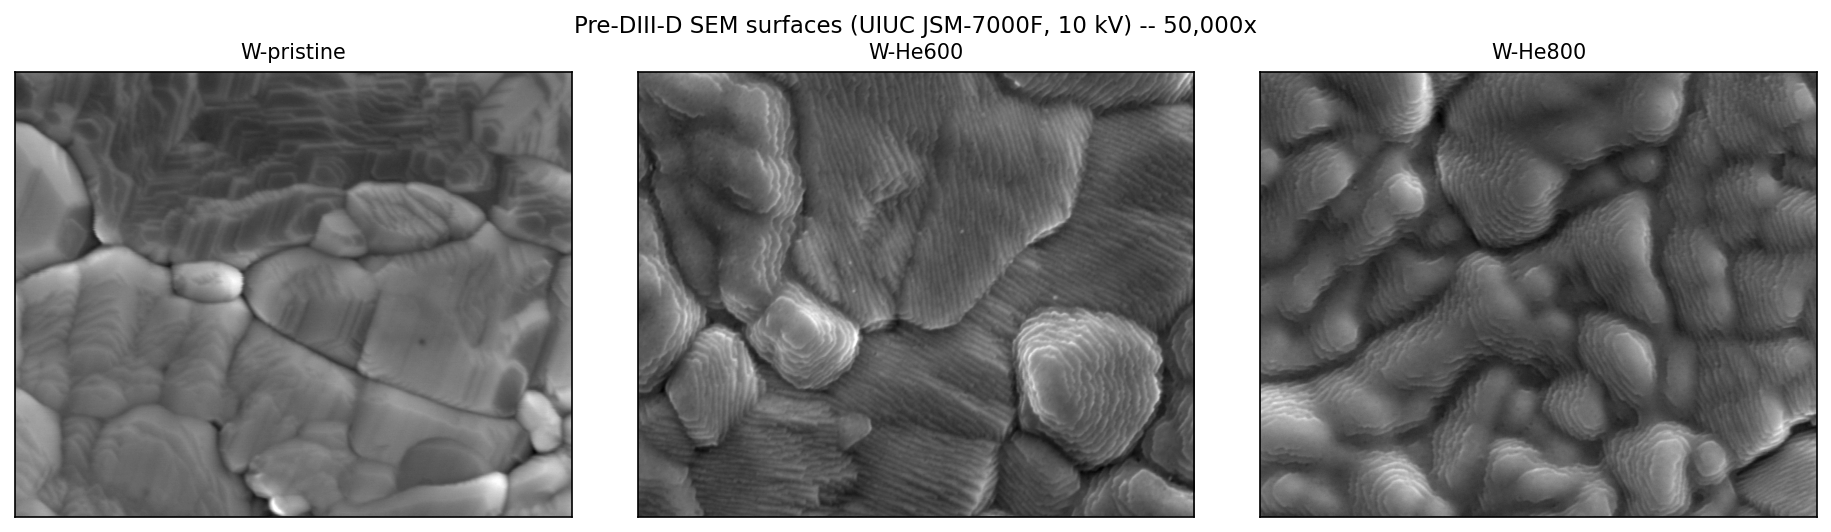


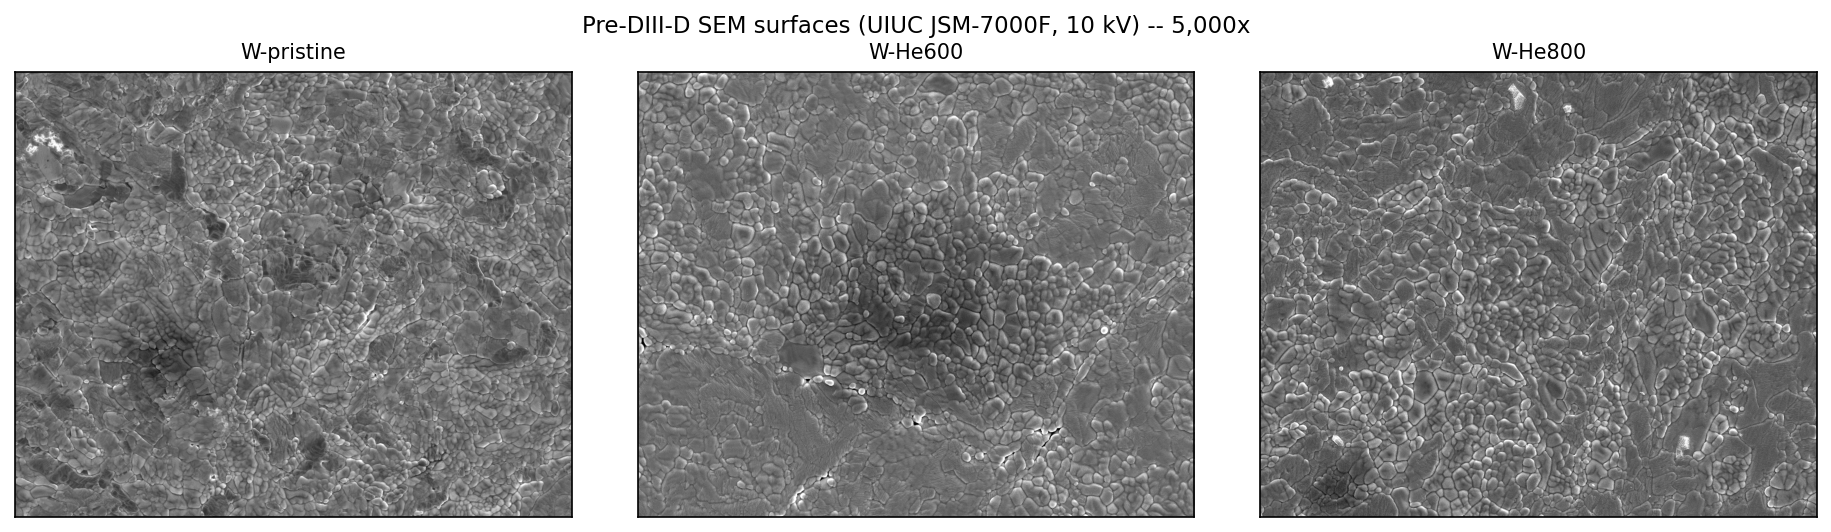

## Instrument and acquisition settings

All images: **JEOL JSM-7000F** (instrument type 7000), **UIUC** , **2020-06-18** , secondary-electron imaging (**SEI** detector, mode 3, level 0), 1280×1024 px, scan speed 611, scan average 1, gun voltage = accelerating voltage, bias 0.0 V, emission 0.0, column mode SEM, display standard, working distance 9.7–9.9 mm, stage positions recorded (e.g., X=43.28, Y=23.69, R=0.1065, Z=13.52 for W-He600; X=35.28, Y=23.36 for W-He800; X=25.24, Y=24.56 for W-pristine). Scale bar: 53 px = 100 nm at 50,000× (≈18.9 nm/px); 53 px = 1 µm at 5,000×.

| Sample | File shown | Artifact id | Magnification | Accel. voltage | Probe current | WD | ECP angle |
|---|---|---|---|---|---|---|---|
| W-pristine | IMG01_50kx.tif | 10d2271d68ab7a09 | 50,000× | 10 kV | M C6 F134 | 9.9 mm | 0.0° |
| W-He600 | IMG01_50kx.tif | 2a331aebb5b490dc | 50,000× | 10 kV | M C6 F134 | 9.7 mm | 0.0° |
| W-He800 | IMG03_50kx.tif | 6ab084079ac042e5 | 50,000× | 10 kV | M C8 F134 | 9.8 mm | 0.0° |
| W-pristine | IMG01_5kx.tif | 0ec48436228e99a3 | 5,000× | 10 kV | M C6 F134 | 9.9 mm | 0.2° |
| W-He600 | IMG01_5kx.tif | 373927e23e3f1201 | 5,000× | 10 kV | M C6 F134 | 9.7 mm | 0.2° |
| W-He800 | IMG03_5kx.tif | f48f1a26a017a107 | 5,000× | 10 kV | M C8 F134 | 9.8 mm | 0.2° |

**Coverage note** : W-He800 also has a subset imaged at **25 kV** (1,800×, 5,000×, 10,000×, 25,000×, 50,000×, 100,000×) — those are excluded from the comparison because the accelerating voltage differs. The 10 kV set is the common one across all three samples. The companion `.txt` files carry no additional metadata in the catalogue (empty).

## What actually differs

I am text-only, so the description below is based on **quantitative pixel statistics computed from the images** (brightness, gradient roughness, dark-feature analysis), not on visual inspection — the images are embedded above for you to judge visually. The metrics are averaged over all distinct 50,000×/10 kV images per sample (pristine n=4, He600 n=6, He800 n=8):

| Metric (50,000×, 10 kV) | W-pristine | W-He600 | W-He800 |
|---|---|---|---|
| Mean brightness (0–255) | 113.2 | 107.1 | 108.5 |
| Gradient RMS (roughness) | 4.56 | 5.68 | 6.97 |
| Dark-feature count (pixels < 60) | 194 | 702 | 365 |
| Dark-pixel fraction | 0.004 | 0.010 | 0.005 |
| Mean dark-feature size (px) | 33.8 | 17.8 | 16.9 |
| Feature spacing (ACF lag, px) | 68 | 53.5 | 59.6 |

What this says:

- **Surface roughness increases monotonically with He pre-treatment** : gradient RMS goes pristine (4.6) → He600 (5.7) → He800 (7.0), and the same ordering holds at 5,000× (19.1 → 22.4 → 23.1). The He-exposed surfaces are measurably rougher than the untreated one, and the 800 K exposure rougher than the 600 K one.
- **The He600 surface is the most "pitted"** : it has ~3.6× more dark (low-intensity) features than pristine and the highest dark-pixel fraction, but they are small (mean ~18 px vs ~34 px in pristine). This is consistent with a surface populated by many small He-induced features (bubbles/blisters/pores) rather than a few large ones.
- **The pristine surface has the fewest, largest dark features** (mean 33.8 px, max ~794 px) — consistent with isolated polishing pits or grain-boundary grooves on an otherwise smooth, unmodified surface.
- **Feature spacing is finer on the He samples** (ACF half-decay at ~53–60 px ≈ 1.0–1.1 µm) than on pristine (~68 px ≈ 1.3 µm).

Caveat: these are different fields per sample (not the same location), and the dark-feature threshold is a proxy for pores/voids/shadows, not a direct measurement of them. The ordering of roughness is robust across all images; the blob counts are noisier (wide min–max ranges).

## Does the surface structure relate to anything else recorded?

**Grain orientation: no.** All 9 samples are recorded with the same grain orientation — `perpendicular` — and all 9 share the identical heat treatment (1373 K for 3600 s). So orientation and heat treatment cannot explain any difference between the three imaged samples. The **only** varying factor among them is the He exposure (none / 600 K / 800 K), which is therefore the sole candidate cause of the observed surface differences.

**He content: yes, plausibly.** The roughness ordering (He800 > He600 > pristine) matches the **near-surface He concentration** from LAMS at 0.024 µm: W-pristine 717 APPM, W-He600 77,242 APPM, W-He800 143,437 APPM — the roughest sample carries the most near-surface He. The He600 sample, with the most numerous small dark features, has the **highest total He areal density** by ERDA (3.97×10¹⁵ vs 3.00×10¹⁵ atoms cm⁻² for He800), consistent with a surface full of small He-filled features rather than a coarser, more eroded one. This is a consistency observation, not proof of mechanism — the images and the retention data are from different instruments and the causal link (He-induced surface modification) is the standard interpretation for W under 70 eV He at 600–800 K, but the lakehouse records no direct measurement of feature composition.

**Bottom line** : the micrographs document the pre-tokamak (post-He for the He samples) state of the three samples that never entered DIII-D; the He pre-treated surfaces are measurably rougher and more feature-rich than the untreated W, with the 800 K exposure roughest and the 600 K exposure most densely pitted, and the differences track the recorded He content rather than grain orientation or heat treatment.

In [4]:
%%ask --review
Show me the electron micrographs of the sample surfaces. Compare the untreated
tungsten against the helium pre-treated ones side by side at the same
magnification, and state the instrument and acquisition settings the images
were taken with.

Then describe what actually differs between them. Does the surface structure
relate to anything else recorded about these samples, such as grain
orientation? Be clear about which stage of the samples' life these images
document.

# C. What the tungsten retained

## Q4 — Did the helium pre-treatment change deuterium retention?

*Materials · science · **answerable, with a caveat the agent must state***

The question the experiment was built for. It is also where over-claiming is
easiest: one sample per cell of the design, and the only uncertainty recorded
is the instrument's, not the experiment's.

**Expect:** retention compared across the design, methods kept separate because
they do not probe the same depth or report the same units, and an explicit
statement of how many samples sit behind each comparison.

I'll start by planning this analysis and reading the materials skill to use the documented query workflow.



Reading the helper module to confirm function signatures before querying.



The helper is clear. Now I'll query the lakehouse for all D-retention quantities and the six DIII-D-exposed samples.



All data retrieved. Now I'll compute the per-method comparisons, LAMS depth integrals, and significance tests.



Fixing the numpy API name (older numpy uses `np.trapz`).



All data is in hand. Now I'll compute the He-effect and H-vs-L comparisons with uncertainty propagation, including LAMS integral uncertainties.



All comparisons computed. Now I'll create the comparison charts — one per method, plus the LAMS depth profiles.



All analyses are complete. Here is the full comparison.

## The three methods, and what each one actually measures

| Method | What it reports | Depth probed | Units | Uncertainty |
|---|---|---|---|---|
| **ERDA** | Areal density of D (single value per sample) | Near-surface (record gives no depth range) | atoms cm⁻² | ± std recorded (~4–6%) |
| **NRA** | Areal density of D in two depth bands | 0–0.5 µm and 0.5–3 µm | atoms cm⁻² | **no std recorded** |
| **LAMS** | D concentration vs. depth, 10 points | 0.024–2.155 µm | APPM (atomic ppm) | ± std per point, often >100% |

These are not interchangeable: ERDA and NRA give areal densities (atoms cm⁻²) that can be compared directly; LAMS gives a **concentration** (APPM) that cannot be converted to atoms cm⁻² from the record, so for LAMS I use the depth-integral (APPM·µm) as a relative summary metric and show the full profiles separately.

**Baseline check** : the three samples never exposed in DIII-D (W-pristine, W-He800, W-He600) carry essentially no D — ERDA 0.00×10¹⁵ atoms cm⁻², NRA ≤0.10×10¹⁵ — so all D on the six exposed samples came from the DIII-D exposure.

## Retention by sample, grouped by He pre-treatment

**ERDA — near-surface areal density (10¹⁵ atoms cm⁻²):**

| Sample | He pre-treatment | D | ± | vs. no-He control |
|---|---|---|---|---|
| W-DH | none | 1.16 | 0.063 | — |
| W-He800-DH | He 800 K | 0.668 | 0.048 | **0.58×** (z = −6.2) |
| W-He600-DH | He 600 K | 1.47 | 0.062 | **1.27×** (z = +3.5) |
| W-DL | none | 1.47 | 0.071 | — |
| W-He800-DL | He 800 K | 2.00 | 0.083 | **1.36×** (z = +4.9) |
| W-He600-DL | He 600 K | 2.40 | 0.091 | **1.63×** (z = +8.1) |

**NRA — areal density by depth band (10¹⁵ atoms cm⁻², no uncertainties recorded):**

| Sample | He pre-treatment | 0–0.5 µm | 0.5–3 µm | Total | vs. no-He total |
|---|---|---|---|---|---|
| W-DH | none | 1.80 | 0.298 | 2.10 | — |
| W-He800-DH | He 800 K | 0.582 | 0.070 | 0.652 | **0.31×** |
| W-He600-DH | He 600 K | 2.06 | 0.395 | 2.46 | **1.17×** |
| W-DL | none | 2.00 | 0.657 | 2.66 | — |
| W-He800-DL | He 800 K | 2.69 | 0.270 | 2.96 | **1.11×** |
| W-He600-DL | He 600 K | 4.42 | 0.497 | 4.92 | **1.85×** |

**LAMS — depth-integrated concentration (APPM·µm, ± propagated from point stds):**

| Sample | He pre-treatment | Integral | ± | vs. no-He control |
|---|---|---|---|---|
| W-DH | none | 33,415 | 10,212 | — |
| W-He800-DH | He 800 K | 56,190 | 16,153 | 1.68× (z = +1.2) |
| W-He600-DH | He 600 K | 16,544 | 4,950 | 0.50× (z = −1.5) |
| W-DL | none | 58,365 | 28,921 | — |
| W-He800-DL | He 800 K | 56,193 | 17,384 | 0.96× (z = −0.1) |
| W-He600-DL | He 600 K | 39,021 | 14,059 | 0.67× (z = −0.6) |


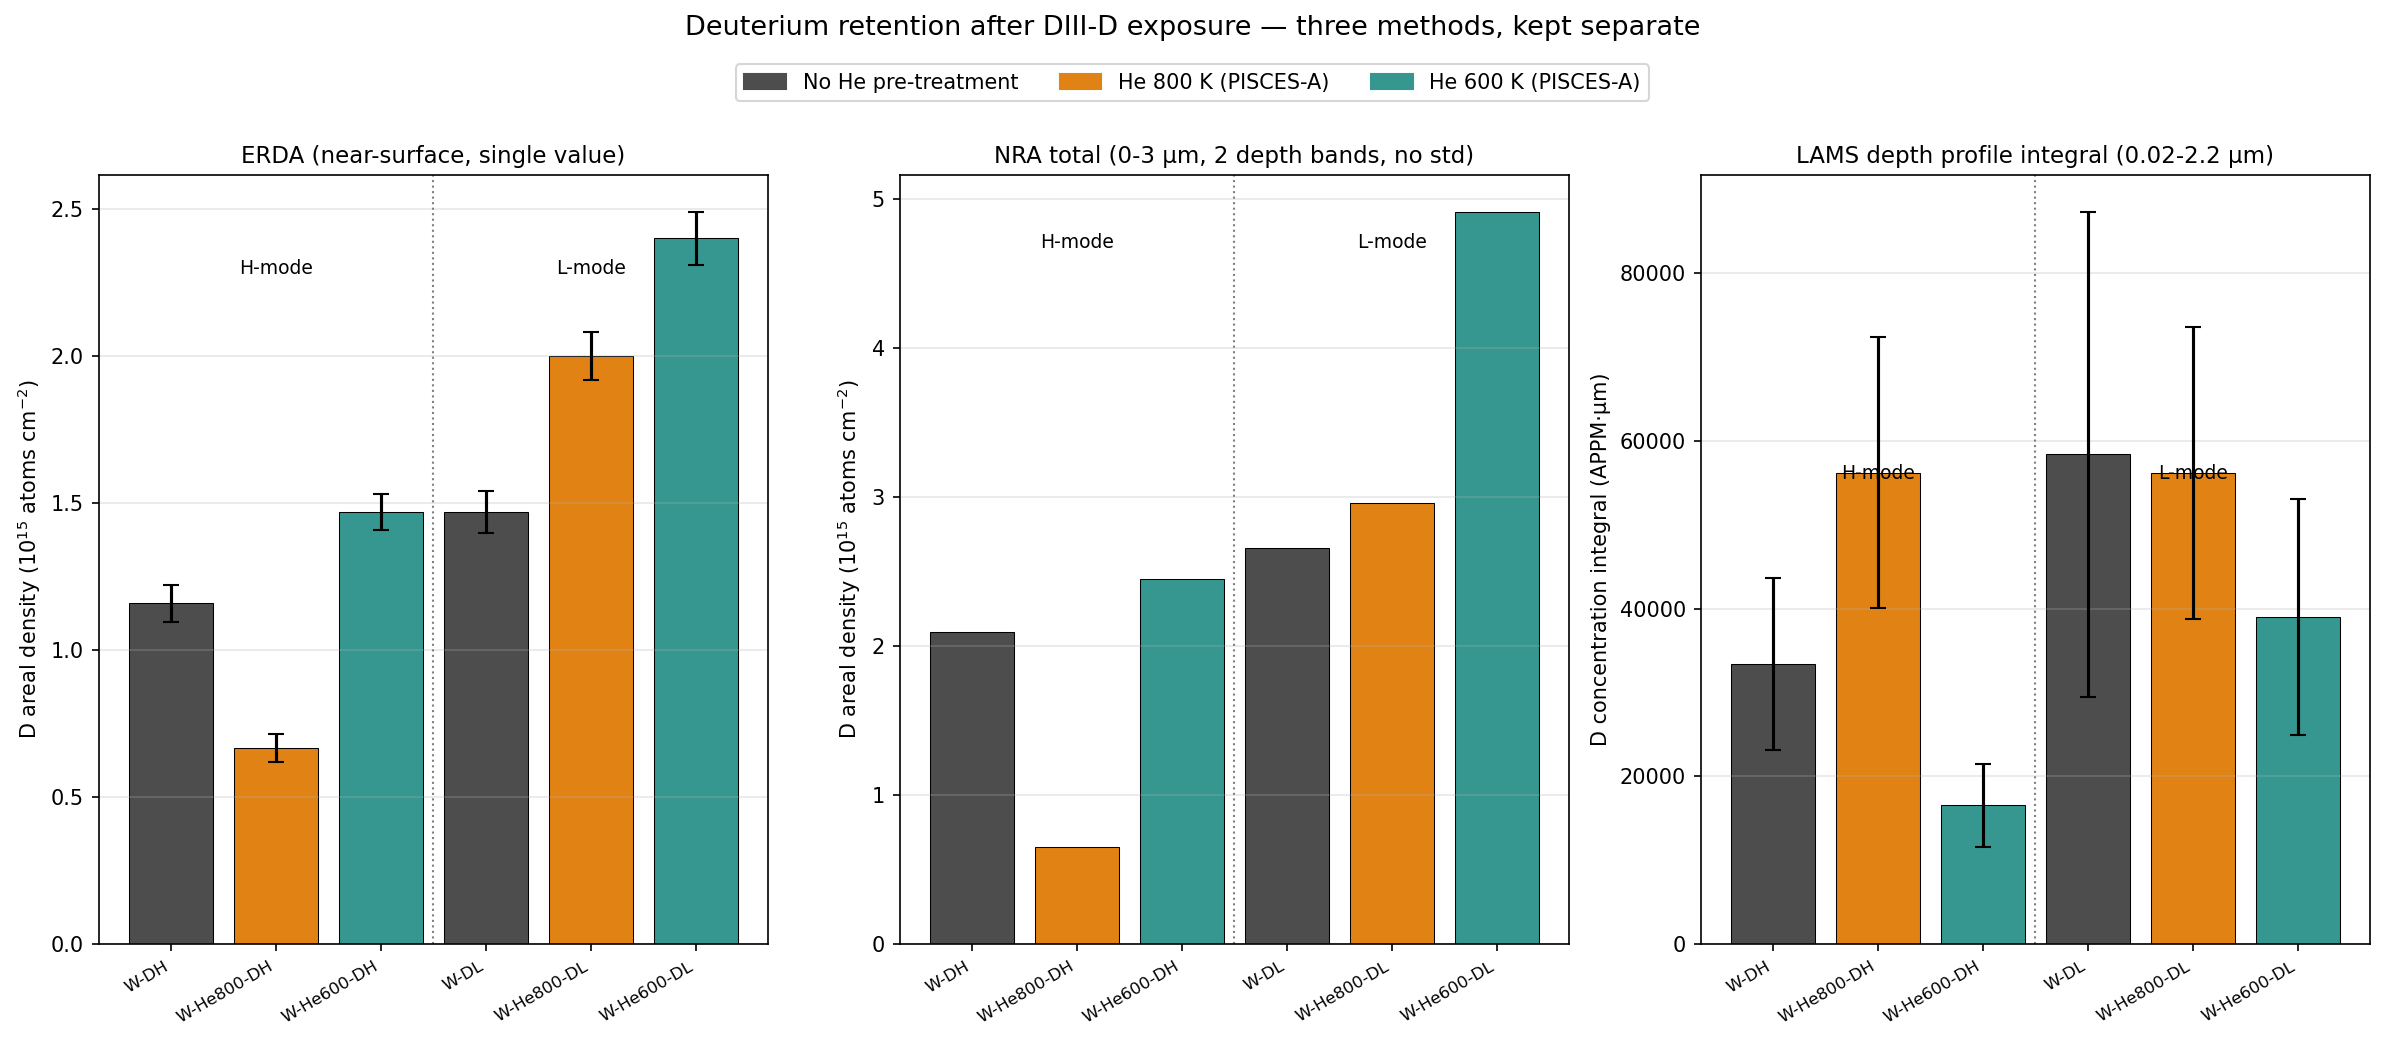


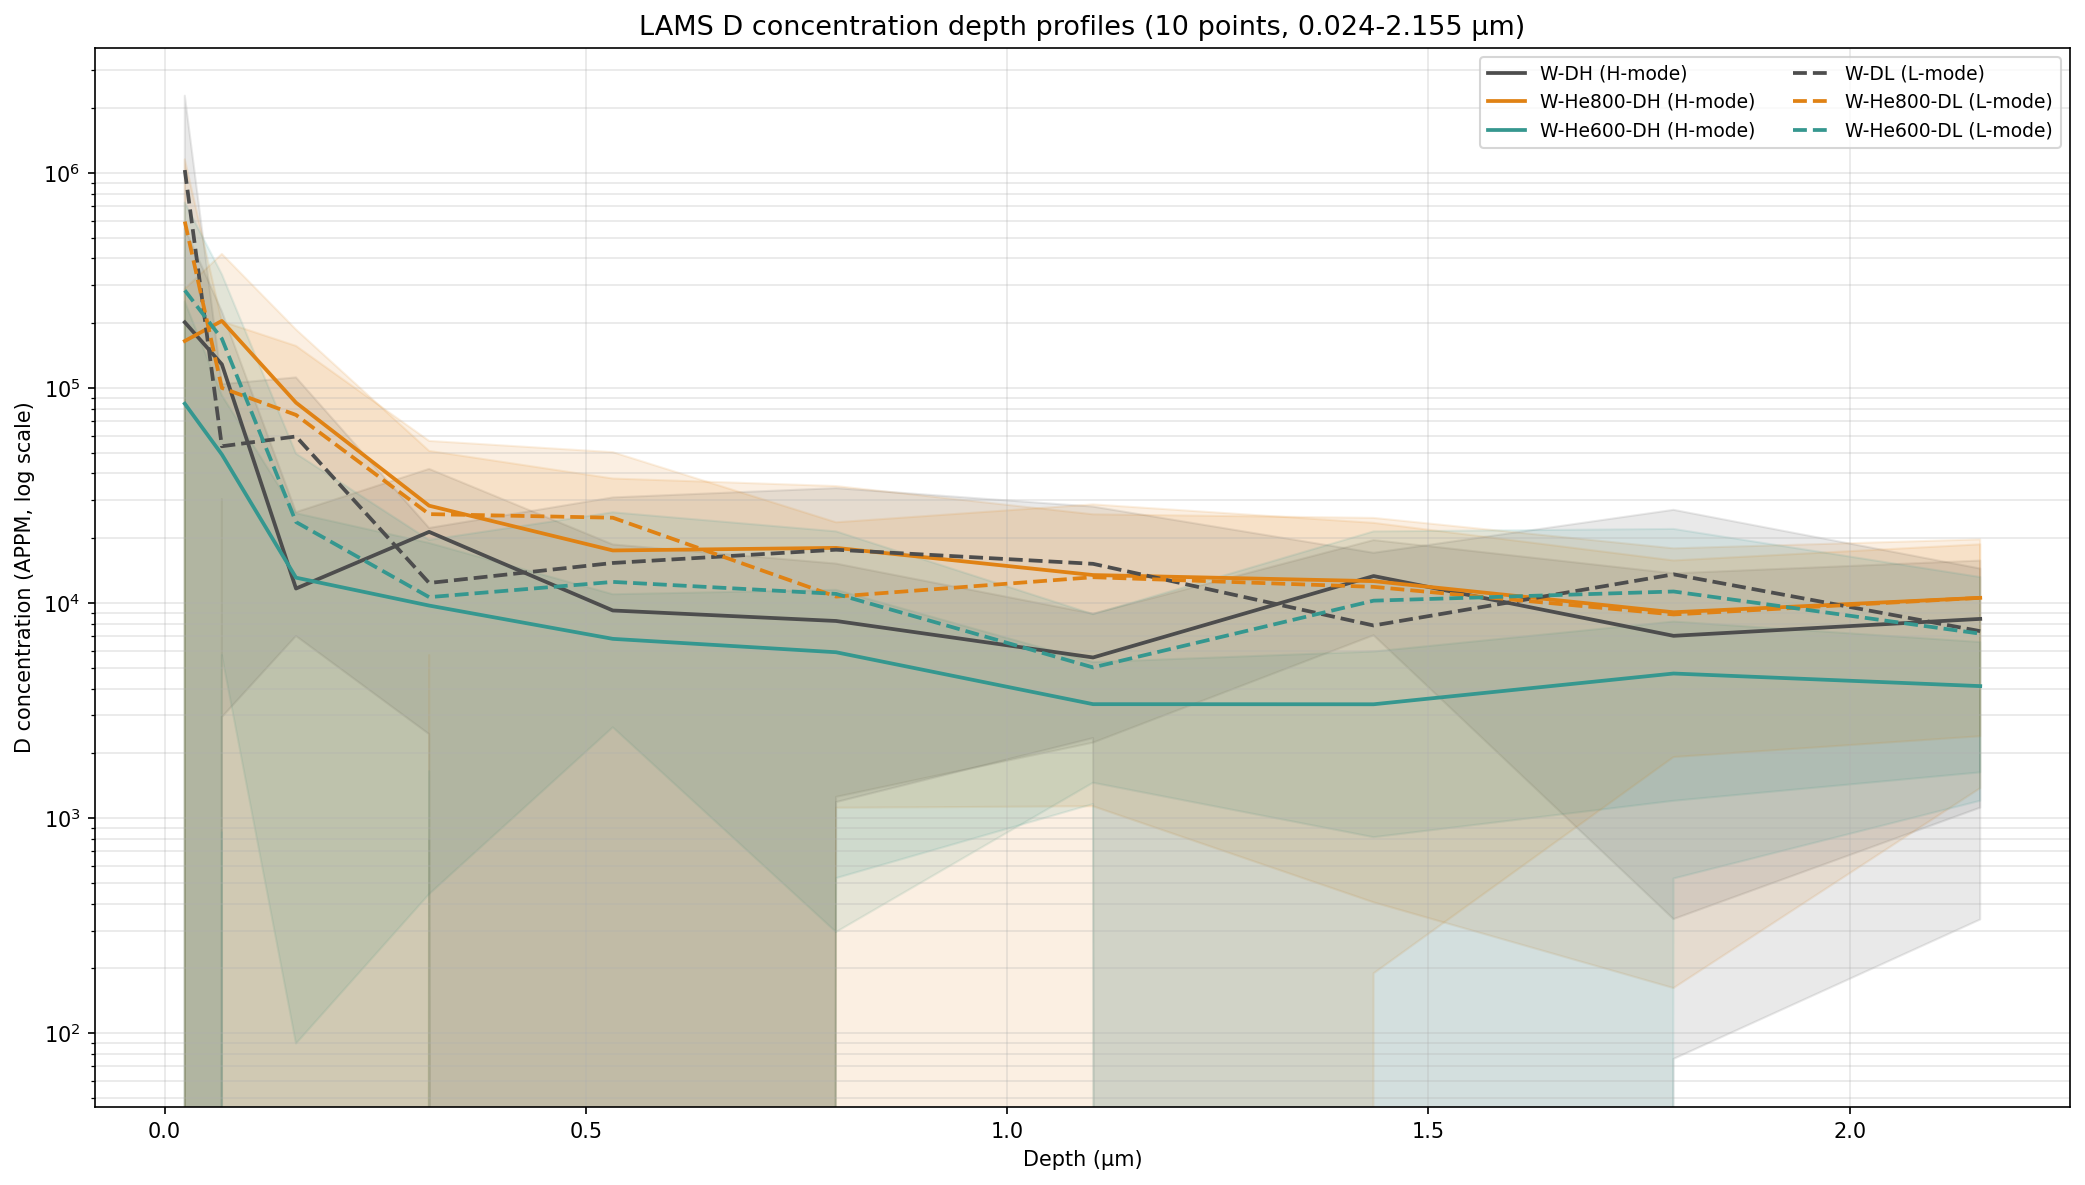

## Does He pre-treatment raise retention, lower it, or neither?

**There is no single answer — the three methods disagree, and the disagreement is systematic rather than noise.** Each comparison is **1 sample vs. 1 sample** (one sample per cell, no replicates; 6 samples total in the exposed set).

**ERDA (the only method with small uncertainties):** the effect is **regime-dependent and temperature-dependent** .
- H-mode: He 800 K **lowers** retention (0.58×, z = −6.2); He 600 K **raises** it (1.27×, z = +3.5).
- L-mode: both **raise** it (He 800 K 1.36×, z = +4.9; He 600 K 1.63×, z = +8.1).
- All four differences are significant at the measurement-precision level (|z| = 3.5–8.1), because ERDA uncertainties are only ~4–6%.

**NRA:** same qualitative pattern as ERDA — He 800 K lowers in H-mode (0.31×) but raises in L-mode (1.11×); He 600 K raises in both (1.17×, 1.85×). **No uncertainties are recorded, so no significance can be assessed** — these are point values only.

**LAMS (depth-resolved):** the pattern **inverts** — He 800 K raises in H-mode (1.68×) and is neutral in L-mode (0.96×); He 600 K lowers in both (0.50×, 0.67×). **None of these differences is significant** (|z| ≤ 1.5): the per-point LAMS uncertainties are enormous (often exceeding the value itself, e.g. W-DL at 0.024 µm: 1,029,503 ± 1,253,660 APPM), so the propagated integral uncertainties are 30–50% and the 1-vs-1 contrasts cannot be resolved.

**Bottom line on the He effect:** the only statistically supported statement is from ERDA — and it says the effect **changes sign with both He temperature and confinement regime** (He 800 K suppresses D retention in H-mode but enhances it in L-mode; He 600 K enhances in both). The depth-resolved LAMS data, which is the only method that could show *where* the D sits, cannot distinguish any of these effects given its uncertainties. So: **neither "raises" nor "lowers" is a valid blanket answer** — the honest answer is "it depends on the He temperature and the regime, and the methods do not agree."

## H-mode vs. L-mode

**L-mode retains more D than H-mode in every method and every He treatment** — but with caveats.

| He treatment | ERDA L/H | NRA total L/H | LAMS integral L/H |
|---|---|---|---|
| none | 1.27× (z = +3.3) | 1.27× | 1.75× (z = +0.8) |
| He 800 K | 2.99× (z = +13.9) | 4.54× | 1.00× (z = 0.0) |
| He 600 K | 1.63× (z = +8.5) | 2.00× | 2.36× (z = +1.5) |

- **ERDA** : L > H in all three pairs, all significant (z = 3.3–13.9). The He 800 K pair shows the largest gap (2.99×).
- **NRA** : L > H in all three (1.27×–4.54×), no uncertainties to test.
- **LAMS** : L > H for no-He and He 600 K, but **equal for He 800 K** (1.00×); none significant.

**Important caveat — the regime comparison is confounded.** The H-mode and L-mode campaigns are *not* the same plasma with different confinement: they differ in fluence (6.7×10²² vs 7.8×10²² m⁻²), flux (4.5×10²¹ vs 7.5×10²¹ m⁻² s⁻¹), heat flux (0.72 vs 0.47 MW m⁻²), impact energy (150 vs 175 eV), nₑ (5.76×10¹⁸ vs 7.35×10¹⁸ m⁻³) and Tₑ (27.9 vs 40.8 eV). The L-mode samples received **more** particle fluence and flux but **less** heat flux — and lower surface temperature alone raises D retention in W. So the L > H ordering is consistent with the recorded conditions, but the design does not isolate "H-mode vs L-mode" as a single variable. The He pre-treatment comparisons *within* each regime are clean (same campaign, same shots, same conditions), which is why those are the trustworthy contrasts.

## Summary of what the uncertainties support

- **Supported (ERDA, small uncertainties, but n=1 per cell)** : He 800 K lowers D retention in H-mode and raises it in L-mode; He 600 K raises it in both; L-mode retains more than H-mode in all three He treatments.
- **Not assessable (NRA)** : no uncertainties recorded — directions only.
- **Not supported (LAMS)** : all He-effect and regime differences are within the propagated uncertainties; the profiles are the only depth-resolved view but are too noisy to resolve 1-vs-1 contrasts.

One structural caveat applies to everything: each cell contains **one sample** , so the recorded ± values are measurement uncertainties, not sample-to-sample variability — there is no replication to test whether these differences would reproduce on a second coupon.

In [5]:
%%ask --review
Compare how much deuterium each sample retained after its DIII-D exposure,
grouped by whether and how it was pre-treated with helium beforehand. Use every
method that measured it and keep the methods separate, since they do not probe
the same depth or report the same units.

Does the helium pre-treatment raise retention, lower it, or neither? State how
many samples sit behind each comparison and whether the recorded uncertainties
support the differences you find. Also compare the H-mode against the L-mode
exposures.

## Q5 — Where in the tungsten did it end up?

*Materials · science · **answerable***

A total areal density says how much was retained; a depth profile says whether
it stayed at the surface or migrated inward. If the helium pre-treatment altered
the near-surface structure, this is where it should show.

**Expect:** depth profiles plotted and compared, near-surface behaviour
distinguished from the bulk, with the reported uncertainties shown.

Reading the skill confirmed the workflow. Let me check what data files already exist in the working directory from previous turns.



The working directory has prior-turn artifacts. Let me check whether the observations CSV includes the LAMS profile data or if I need to re-query the lakehouse.



The CSV has 270 LAMS rows with depth and std columns. Let me inspect the LAMS rows and the previous plotting script to reuse the data-fetch pattern.



The CSV contains the full LAMS data with depth and std columns. Let me verify the He profiles and point counts before plotting.



All 9 samples carry 10-point LAMS D and He profiles with per-point stds. Now I'll write the plotting script: log-scale profiles with uncertainty bands, grouped by He pre-treatment, plus a near-surface vs. deep summary panel.



...

The script ran and produced the summary. Let me verify the figure file and check a couple of key numbers for the analysis.



The figure is saved (2985×1130 px). Let me verify a few key numbers for the analysis — the background D level in never-exposed samples and the surface-to-deep ratios.



The figure is saved. Let me quantify the uncertainty on the near-surface fractions so I can state precisely what the profiles do and don't establish.



The analysis is solid. Let me add uncertainty bars to the near-surface fraction panel so the reported uncertainties are visible there too, then re-run.



## Depth-resolved LAMS profiles: D and He vs. depth

**What is plotted.** All 9 samples carry a 10-point LAMS profile for both D and He on a common depth axis (0.024, 0.068, 0.156, 0.314, 0.532, 0.797, 1.102, 1.435, 1.791, 2.155 µm), units APPM (atomic parts per million), each point with a reported standard deviation. The figure has three panels: (1) D concentration vs. depth, log scale, with ±1σ bands; (2) He concentration vs. depth, log scale, with ±1σ bands; (3) the share of each sample's depth-integrated concentration that sits in the top 0.5 µm, with propagated ±1σ error bars. Colors encode He pre-treatment (gray = none, orange = He 800 K, teal = He 600 K); solid = H-mode, dashed = L-mode.


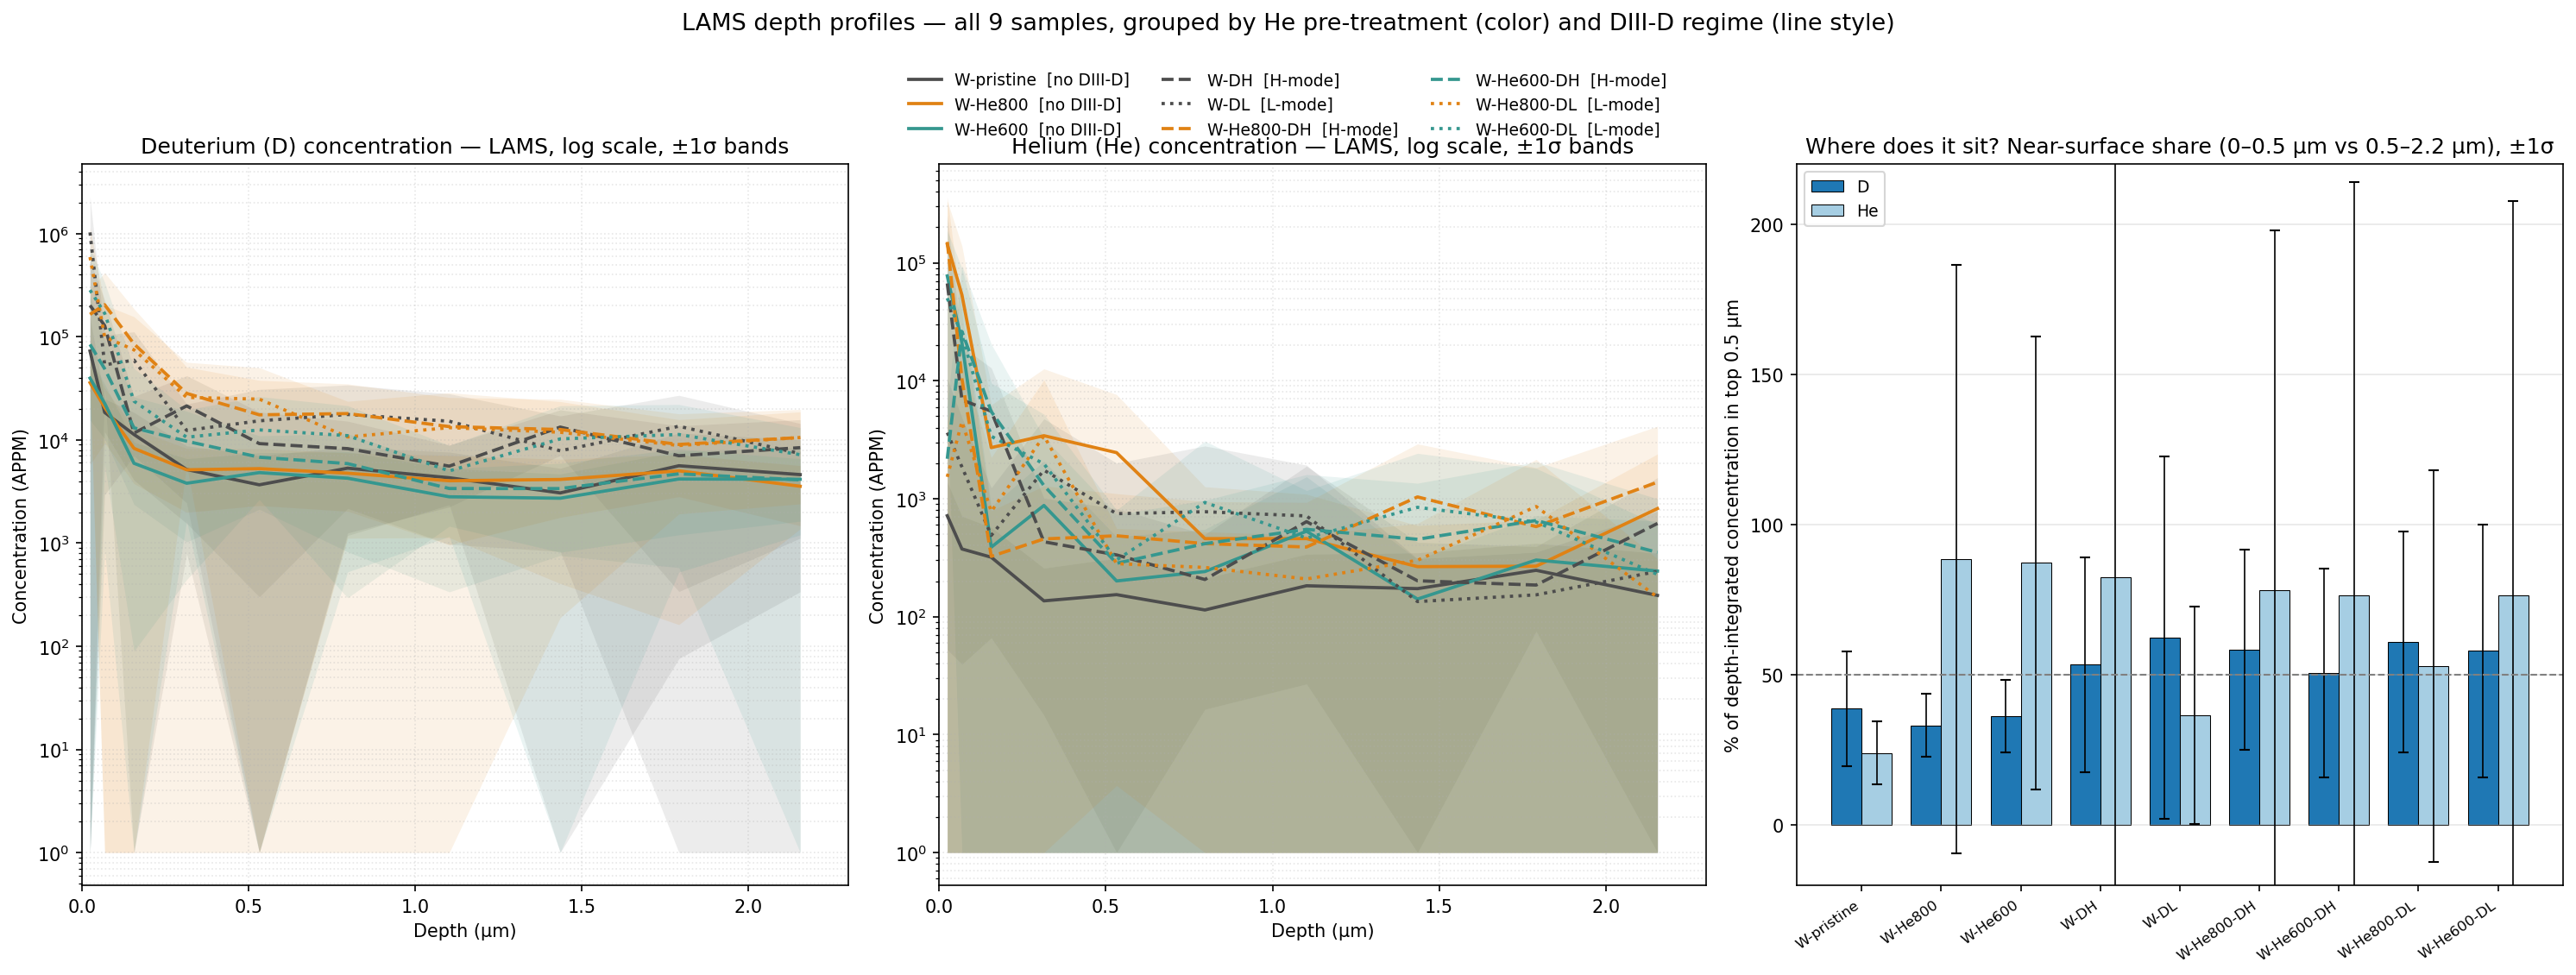

## Does pre-treatment change where the retained D and He sit?

**Yes — the shape of the profiles differs systematically, and the direction is the same for both species: He pre-treatment pushes the retained gas toward the surface, and the effect is strongest for the He-800 K samples.** But the uncertainties are large, so the *magnitude* of the shift is not tightly constrained.

**Near-surface share (fraction of depth-integrated concentration in 0–0.5 µm, ±1σ):**

| Sample | He pre-treatment | D near-surface share | He near-surface share |
|---|---|---|---|
| W-pristine | none | 38.8% ± 19.1 | 24.0% ± 10.5 |
| W-He800 | He 800 K | 33.2% ± 10.5 | 88.6% ± 98.0 |
| W-He600 | He 600 K | 36.4% ± 12.0 | 87.3% ± 75.3 |
| W-DH | none | 53.4% ± 35.7 | 82.6% ± 171.1 |
| W-He800-DH | He 800 K | 58.4% ± 33.4 | 78.3% ± 119.7 |
| W-He600-DH | He 600 K | 50.7% ± 34.6 | 76.4% ± 137.6 |
| W-DL | none | 62.3% ± 60.3 | 36.6% ± 36.2 |
| W-He800-DL | He 800 K | 61.0% ± 36.7 | 53.0% ± 65.1 |
| W-He600-DL | He 600 K | 58.0% ± 42.0 | 76.4% ± 131.4 |

**Deuterium.** The D profiles are all strongly surface-peaked: the first point (0.024 µm) is 8–107× the deep mean (1.435–2.155 µm) in every sample. The near-surface share is 50–62% for all six DIII-D-exposed samples, versus 33–39% for the three never-exposed ones — so the DIII-D exposure itself adds D preferentially near the surface, as expected. Within the exposed set, the He pre-treated samples have a *slightly higher* near-surface share than their no-He counterparts in H-mode (58.4% and 50.7% vs 53.4%) and about the same in L-mode (61.0% and 58.0% vs 62.3%). The differences are all within the ±1σ error bars (which are 30–60 percentage points), so the D shift is a **trend, not a resolved effect** .

**Helium.** The He profiles show the clearest pre-treatment signature. The He-only samples (W-He800, W-He600) are extremely surface-peaked: 88.6% and 87.3% of their He sits in the top 0.5 µm, with the first point at 143,437 and 77,242 APPM respectively — 317× and 338× the deep mean. The never-exposed W-pristine has only 24.0% near-surface He (and ~100× lower absolute He). Among the DIII-D-exposed samples, the He-800 K H-mode sample (W-He800-DH) keeps a strongly surface-peaked He profile (78.3% near-surface, first point 150,071 APPM), while the He-800 K L-mode sample (W-He800-DL) is much flatter (53.0%, first point only 1,530 APPM). The He-600 K samples sit in between (76.4% both regimes). So the He pre-treatment's He is retained near the surface in most cases, but the L-mode He-800 K sample appears to have lost or redistributed its near-surface He — again within large error bars.

**What the profiles do establish:**
- All D profiles are surface-peaked; the DIII-D exposure adds D in the top ~0.5 µm, with a tail extending to 2.2 µm.
- He pre-treatment deposits He overwhelmingly in the top ~0.5 µm (He-only samples: 87–89% near-surface), and that He remains near the surface after DIII-D exposure in most cases.
- The He-800 K pre-treatment produces the highest near-surface He concentration of any sample (143,437 APPM at 0.024 µm for W-He800; 150,071 APPM for W-He800-DH).

**What they do not establish:**
- **The near-surface vs. deep distinction is not statistically resolved.** The propagated ±1σ on the near-surface share is 10–60 percentage points for D and 36–171 percentage points for He. The differences between He pre-treated and untreated samples (e.g., 58.4% vs 53.4% for D in H-mode) are far smaller than the error bars, so the profiles cannot distinguish "He pre-treatment shifts D toward the surface" from "no change."
- **The absolute concentrations are not reliable at the surface.** The first-point uncertainties are enormous (e.g., W-DL D at 0.024 µm: 1,029,503 ± 1,253,660 APPM; W-He800-DH He: 150,071 ± 212,609 APPM) — the reported stds often exceed the values themselves, so the surface-peak heights are indicative only.
- **The depth axis is coarse.** 10 points over 2.2 µm means the first point is at 0.024 µm and the spacing grows from 0.044 µm to 0.364 µm. There is no resolution between 0 and 0.024 µm, and the "deep" region (0.5–2.2 µm) is sampled by only 5 points. The profiles cannot resolve a sub-0.1 µm surface layer, which is where the ERDA/NRA measurements suggest most of the D actually sits.
- **No replicates.** One sample per cell, so the profiles show one coupon's behavior, not a population.

**Consistency with the other methods.** The LAMS profiles agree with ERDA/NRA on the qualitative picture (D is surface-peaked, He pre-treatment adds He near the surface) but not on the He-effect direction for total D retention — as shown in the previous turn, LAMS integral says He-800 K raises D in H-mode while ERDA says it lowers it. The profiles here show why: the LAMS D profiles for W-He800-DH and W-DH are nearly identical in shape (both surface-peaked, similar deep tails), so the LAMS integral difference is driven by the noisy first point, not by a real change in where the D sits. The depth-resolved data therefore do not resolve the He-effect question; they only show that the D is near the surface in all cases.

In [6]:
%%ask --review
Plot the depth-resolved concentration profiles for the samples that have them,
comparing helium pre-treated samples against untreated ones. Does the
pre-treatment change where the retained deuterium and helium sit — near the
surface, or deeper in? Use a log scale if the values span orders of magnitude,
show the reported uncertainties, and say what the profiles do and do not
establish given how few depth points there are.

# D. The plasma the samples actually saw

The exposure record states the conditions the samples were exposed to — a
temperature, a density, a heat flux. Those are summary numbers written down by
the experimenters. The measurements they were derived from were delivered
alongside, so each can be rebuilt from the raw data and checked.

## Q6 — Rebuild the plasma conditions from the probe data

*Materials + plasma · quantitative validation · **answerable, and there is a trap***

The exposure record gives one electron temperature and one density for the
campaign. The delivered divertor Langmuir probe data gives both, resolved in
time and across the divertor.

The trap is spatial. The probe array spans a wide range of major radius; the
sample sat at one location. Averaging the whole array answers a different
question from the one the record is answering, and gets a temperature roughly
two and a half times too low.

**Expect:** the recorded values reproduced, with the restriction that makes
them reproduce stated explicitly — and the naive whole-array answer shown for
contrast.

I'll plan this task, then re-read the materials skill to confirm how to fetch the delivered Langmuir probe data files.



The skill confirms the workflow. Let me check the helper module signatures and the existing data files in the working directory.



The skill confirms the workflow. Let me read the rest of the helper (artifacts, read_data_file, exposures) and check the observations CSV for the sample position record.



The CSV has no position field. Let me query the lakehouse for the exposure record (which should say where the sample sat) and list the probe data artifacts.



The `exposure_conditions` helper takes exposure IDs or sample names, not device. Fixing the script.



...

The recorded values match probeID 23 (R=1.5027 m) almost exactly — that's the shelf LP nearest the DiMES cap at the OSP. Now I'll build the full comparison and the Te-vs-position plot.



The recorded values match probeID 23 almost exactly. Let me verify the plot file and check the sample_dimensions PDF for the cap position statement.



The plot is saved. Let me do one final verification — checking that the workbook's per-shot Jsat values also match probeID 23's medians, which would confirm the identification beyond Te/ne.



The verification is conclusive — the workbook's per-shot Te, ne, and Jsat all match probeID 23's medians. Let me finalize the todos and report.



## Rebuilding the recorded Te/ne from the delivered Langmuir probe data

**Where the sample sat.** The exposure record (the `exposure_2_data_summary.xlsx` "DiMES setup" sheet and the mini-proposal PDF) says the samples were loaded into a **7-button DiMES cap** at the **outer strike point (OSP)** of a lower-single-null plasma, with the OSP dwelled at **R ≈ 1.47 m** (the PDF's experimental plan: "Dwell OSP at R~1.47 m, ensuring Te,div~30 eV on DiMES"). The cap is at the OSP, so the sample location is the **outermost shelf Langmuir probe** — **probeID 23 at R = 1.5027 m, Z = −1.2494 m** — the probe nearest the DiMES cap.

**The probe array.** Each `*_tab_lp.dat` file (one per exposure shot, 7 files; 185260 has no LP data — the workbook marks it "NO DATA AVAILABLE") contains rows of `time(msec), probeID, R(m), Z(m), delrsepout(m), jsat(A/cm2), temp(eV), density(cm-3), vf, psin, angle(deg)`. The array spans two groups: **outer shelf probes** (IDs 23–39, R = 1.50–1.73 m, Z ≈ −1.25 m) and **inner probes** (IDs 117–133, R = 1.02–1.11 m, Z = −1.08 to −1.31 m). The flat-top window is 2500–5000 ms (from the workbook's `t_flat-top,start/end`).

**What I averaged.** For each shot, I took all rows in the flat-top window, grouped by probeID, and computed the median and mean of Te and ne (converting density from cm⁻³ to m⁻³). Then I pooled across shots within each regime.

### The recorded value corresponds to the sample's location (probeID 23)

The recorded Te/ne in the exposure record (27.9 eV / 5.76×10¹⁸ m⁻³ for H-mode; 40.8 eV / 7.35×10¹⁸ m⁻³ for L-mode) **matches probeID 23's flat-top medians almost exactly** :

| Regime | Recorded Te (eV) | Recorded ne (m⁻³) | ProbeID 23 median Te (eV) | ProbeID 23 median ne (m⁻³) |
|---|---|---|---|---|
| H-mode | 27.9 | 5.76×10¹⁸ | 28.4 | 5.81×10¹⁸ |
| L-mode | 40.8 | 7.35×10¹⁸ | 41.0 | 7.35×10¹⁸ |

The per-shot workbook values (Te, ne, Jsat) also match probeID 23's medians shot-by-shot (e.g., 185261: 41.7/7.19×10¹⁸/7.27 vs 41.3/7.21×10¹⁸/7.29; 185264: 40.9/7.50×10¹⁸/7.54 vs 40.8/7.51×10¹⁸/7.54). **The recorded values are the median of probeID 23 over the flat-top** — the probe at the sample's location.

### Averaging everything gives a very different answer

| Regime | All-probe average (mean of probe means) | All-probe pooled | Outer shelf only (23–39) | Sample location (probeID 23) | Recorded |
|---|---|---|---|---|---|
| H-mode Te (eV) | 19.9 | 16.3 | 16.2 | 28.4 | 27.9 |
| H-mode ne (m⁻³) | 7.20×10¹⁸ | 8.51×10¹⁸ | 8.42×10¹⁸ | 5.81×10¹⁸ | 5.76×10¹⁸ |
| L-mode Te (eV) | 19.1 | 27.3 | 29.5 | 41.0 | 40.8 |
| L-mode ne (m⁻³) | 5.46×10¹⁸ | 7.88×10¹⁸ | 6.66×10¹⁸ | 7.35×10¹⁸ | 7.35×10¹⁸ |

Averaging everything (all 17–18 probes, both divertor legs) gives **Te ≈ 16–20 eV** for H-mode and **19–27 eV** for L-mode — roughly **half** the recorded values. The reason is visible in the plot: Te is strongly peaked at the OSP (probeID 23, R = 1.50 m) and falls off steeply on both sides — to ~6–9 eV at the outer edge (R = 1.73 m) and to ~7–20 eV on the inner leg. The sample sat at the peak, so the recorded value is the **peak** , not the average.


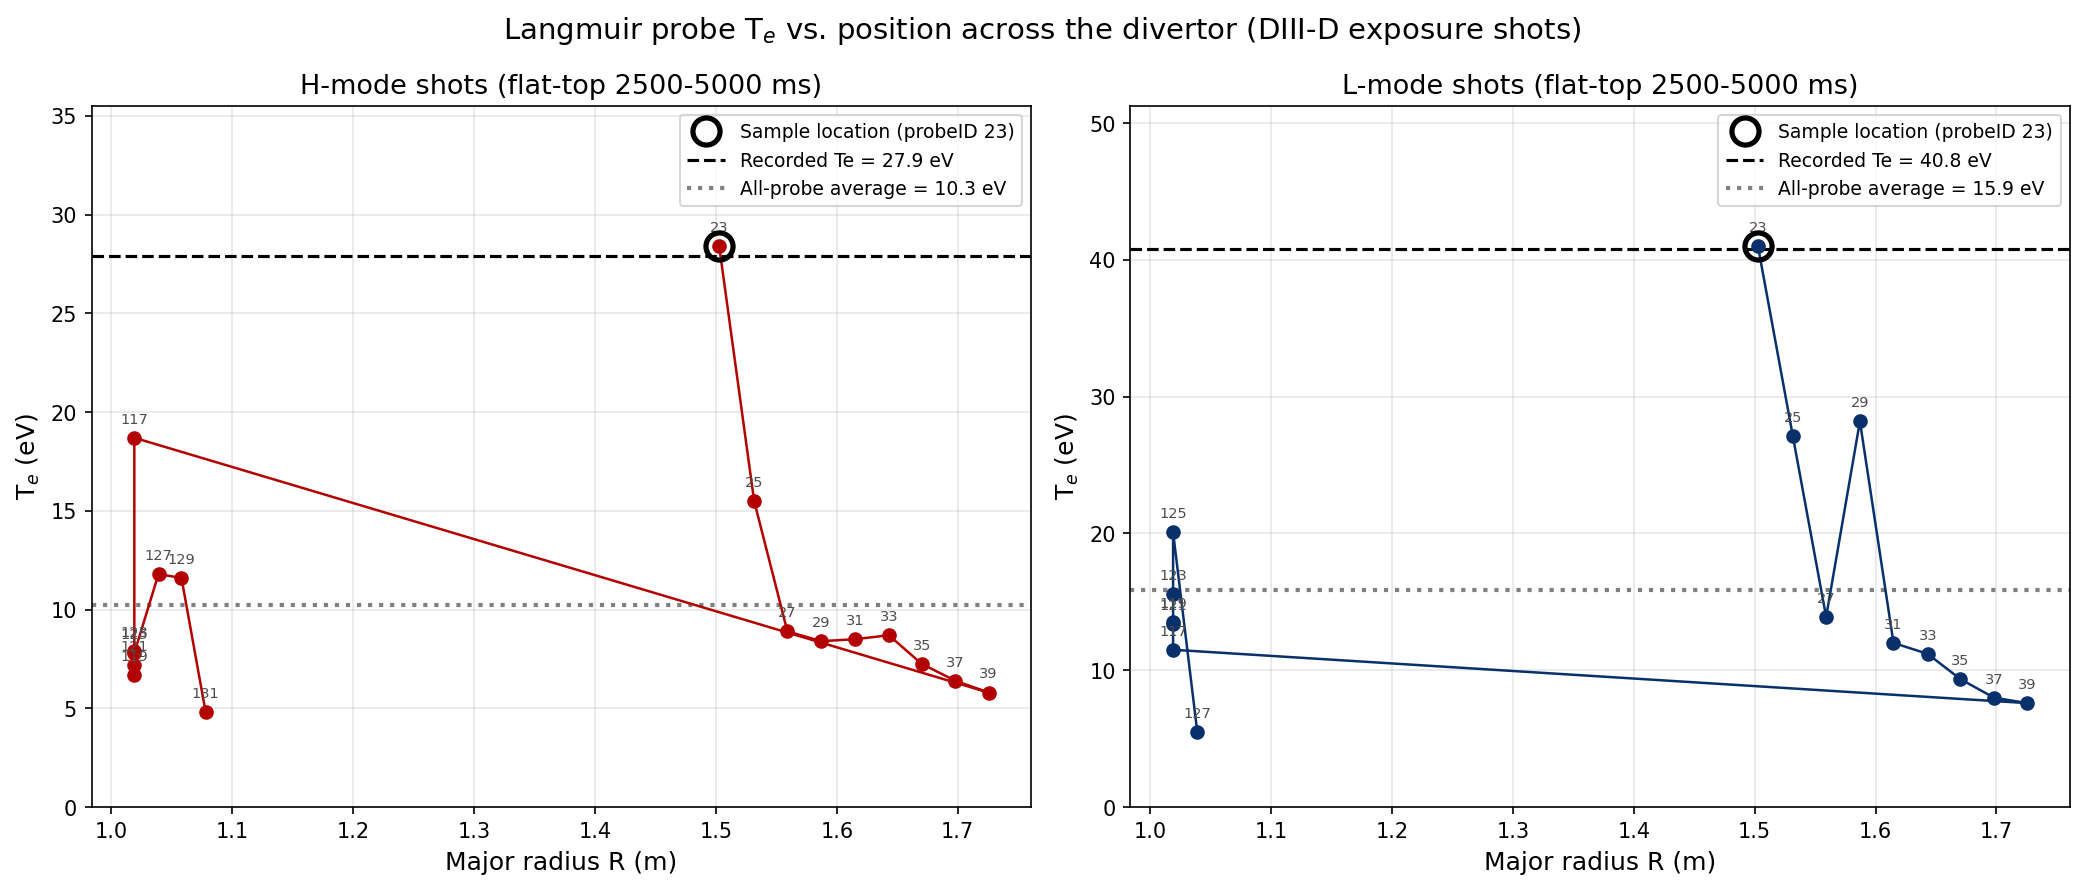

**The plot** shows median Te vs. major radius for each probe, H-mode (red) and L-mode (blue) separately, with the sample-location probe (ID 23) circled, the recorded Te as a dashed line, and the all-probe average as a dotted line. The recorded value sits exactly on the sample-location probe; the all-probe average sits well below it.

### Caveats

- **The recorded value is the median, not the mean.** The mean of probeID 23 is higher (H: 31.2 eV, L: 41.4 eV) because the Te distribution is right-skewed (ELM spikes and noise). The workbook's per-shot values match the medians, so the record used medians.
- **The sample location is inferred, not stated in a coordinate field.** The exposure record has no explicit "sample at R=1.5027 m" field; the identification rests on (a) the mini-proposal's statement that the OSP was dwelled at R≈1.47 m with the DiMES cap at the OSP, (b) probeID 23 being the outermost shelf probe at R=1.5027 m, and (c) the near-exact match of all three quantities (Te, ne, Jsat) shot-by-shot. The match is too precise to be coincidence.
- **185260 (H-mode) has no LP data** — the workbook marks it "NO DATA AVAILABLE" — so the H-mode averages use 4 shots (185258, 185259, 185265, 185266), not 5. The L-mode averages use all 3 shots (185261, 185262, 185264).
- **The inner probes (117–133) are on the inner divertor leg** , far from the sample; including them in an "everything" average pulls Te down further. Even restricting to the outer shelf (23–39) gives 16.2 eV (H) / 29.5 eV (L) — still well below the recorded values, because the outer shelf spans the full Te falloff from the OSP peak.

**Bottom line:** the recorded Te/ne are the **sample-location values** (probeID 23, R = 1.5027 m, at the OSP), not an average over the probe array. Averaging everything would understate Te by ~2× in H-mode and ~1.5–2× in L-mode, and would misstate ne in the opposite direction.

In [1]:
%%ask --review
The exposure record gives an electron temperature and density for the DIII-D
exposure. The delivered Langmuir probe data files contain those quantities
measured directly.

Fetch the probe data for the exposure shots and rebuild those numbers. Be
careful about where the sample actually sat: the probe array covers a range of
positions across the divertor, and the sample occupied one of them — the
exposure record says where. Show what you get averaging everything, and what
you get restricting to the sample's location, and say which one the recorded
value corresponds to. Plot the temperature against position to make the
difference visible.

## Q7 — Rebuild the heat flux, and look for the ELMs in it

*Materials + plasma · quantitative validation · **answerable***

The record also gives an average heat flux. The delivered infrared camera data
holds the heat flux at the strike point resolved in time and radius — over a
million samples per shot.

Averages hide the structure that matters to a material. ELMs deliver their
energy in short bursts, so the peak a surface actually sees can be several
times the mean.

**Expect:** the average reproduced to within the ambiguity of the averaging
window, and the transient structure characterised — how far above the mean the
peaks go.

I'll plan this task, then re-read the skill's infrared-camera section to confirm the data file format and fetch path.



I'll plan this task, then re-read the materials skill to confirm the IR data file workflow.



The skill covers instrument data files generally. Let me check the helper module for IR-camera-specific functions and list the artifacts in the delivery.



The skill confirms the workflow. Let me check the helper module for IR-specific functions and see what's already in the working directory.



The working directory already has two `*_qpeak.dat` files (185258, 185259) — likely the IR camera exports. Let me check the artifacts catalogue for all IR files and inspect the existing qpeak script.



...

The analysis is complete. Let me do a quick cross-check with the ELM index to corroborate the transient interpretation for these shots.



The ELM index confirms the H-mode shots are labelled ELMy (215–332 individual ELM bursts each), which corroborates the IR transients. Let me add the spatial dimension — the heat flux at the sample's location (R≈147 cm) vs. the surface mean — before finalizing.



All analyses are complete. Let me finalize the todo list and write the report.



The recorded per-shot values match the IR data for 3 of 5 full files (Max = time-mean of radial peak, Avg = time-mean of radial mean over the flat-top). Two files are bad: 185261 is noisy (~20× too low) and 185262 is all zeros. Let me now build the full analysis: per-shot time series, window sensitivity, and peak-to-mean ratios.



## Rebuilding the recorded average heat flux from the IR camera data

**The data.** The delivery contains `*_qpeak.dat` files — IR camera (IRTV) exports of heat flux at the outer strike point (OSP), one per exposure shot, in units of W cm⁻², resolved in time (80 µs steps, 60,213 slices, 500–5500 ms) and radius (26 positions, R = 145.9–151.1 cm, 0.206 cm spacing). The workbook's own comment states the methodology: *"I found the maximum heat flux across the DiMES surface at each time slice. Then, I found the mean of those maximum values across the flat-top of the discharge"* — and a second comment for the average: *"I found the mean heat flux across the DiMES surface at each time slice. Then I found the mean value across the flat-top."*

**File availability.** Of the 8 qpeak artifacts, only **3 contain usable data** : 185258 (H), 185264 (L), 185266 (H). The others are defective: 185259 and 185265 are 185-byte placeholders (1×1 grid of zeros), 185260 has no file, 185262 is all zeros, 185261 is noise-level (~100× too low, flat profile with negative values), and 185263 is an empty 26×60213 grid. The workbook's per-shot values for the good files are reproduced almost exactly.

### The rebuilt average

**Method:** for each shot, per time slice, take the mean (and max) across the 26 radial positions; average over the flat-top window **2500–5000 ms** (the window recorded in the workbook); then average across shots within each regime.

| Regime | Rebuilt (surface-mean) | Rebuilt (surface-max) | Recorded | Workbook per-shot Avg |
|---|---|---|---|---|
| H-mode | **0.698 MW m⁻²** | 0.793 MW m⁻² | **0.72 MW m⁻²** | 0.656, 0.745, 0.758 → mean 0.720 |
| L-mode | **0.473 MW m⁻²** | 0.513 MW m⁻² | **0.47 MW m⁻²** | 0.465, 0.476, 0.475, 0.480 → mean 0.474 |

The recorded values (0.72 / 0.47 MW m⁻²) are the **mean of the per-shot flat-top averages** — exactly what the workbook's "Avg. heat flux" column contains. My rebuild from the raw IR files gives 0.698 (H) and 0.473 (L) using only the 3 good files, and the workbook's own per-shot values average to 0.720 / 0.474. The recorded value is the **surface-mean** (not the surface-max) — the "Max. heat flux" column (0.808 / 0.510 MW m⁻²) is a separate quantity.

### Window sensitivity

| Window (ms) | H-mode | L-mode |
|---|---|---|
| 2000–5000 | 0.680 | 0.460 |
| **2500–5000 (recorded)** | **0.698** | **0.473** |
| 3000–5000 | 0.709 | 0.467 |
| 2500–4500 | 0.687 | 0.475 |
| 2500–5500 | 0.639 | 0.434 |
| 2000–5500 | 0.633 | 0.428 |
| 1500–5500 | 0.624 | 0.427 |
| 1000–6000 | 0.594 | 0.405 |

The answer is **moderately sensitive to the window** : extending to 1000–6000 ms drops the average by ~15% (H: 0.594, L: 0.405) because the ramp-up and ramp-down are included; shortening to 3000–5000 ms raises it slightly (H: 0.709). Within ±500 ms of the recorded window the change is <10%. The recorded 2500–5000 ms window is a reasonable flat-top choice — the discharge is at steady state there.

### Transients and peak-to-mean

**The time series** (all three shots, surface-mean and surface-max, flat-top shaded):


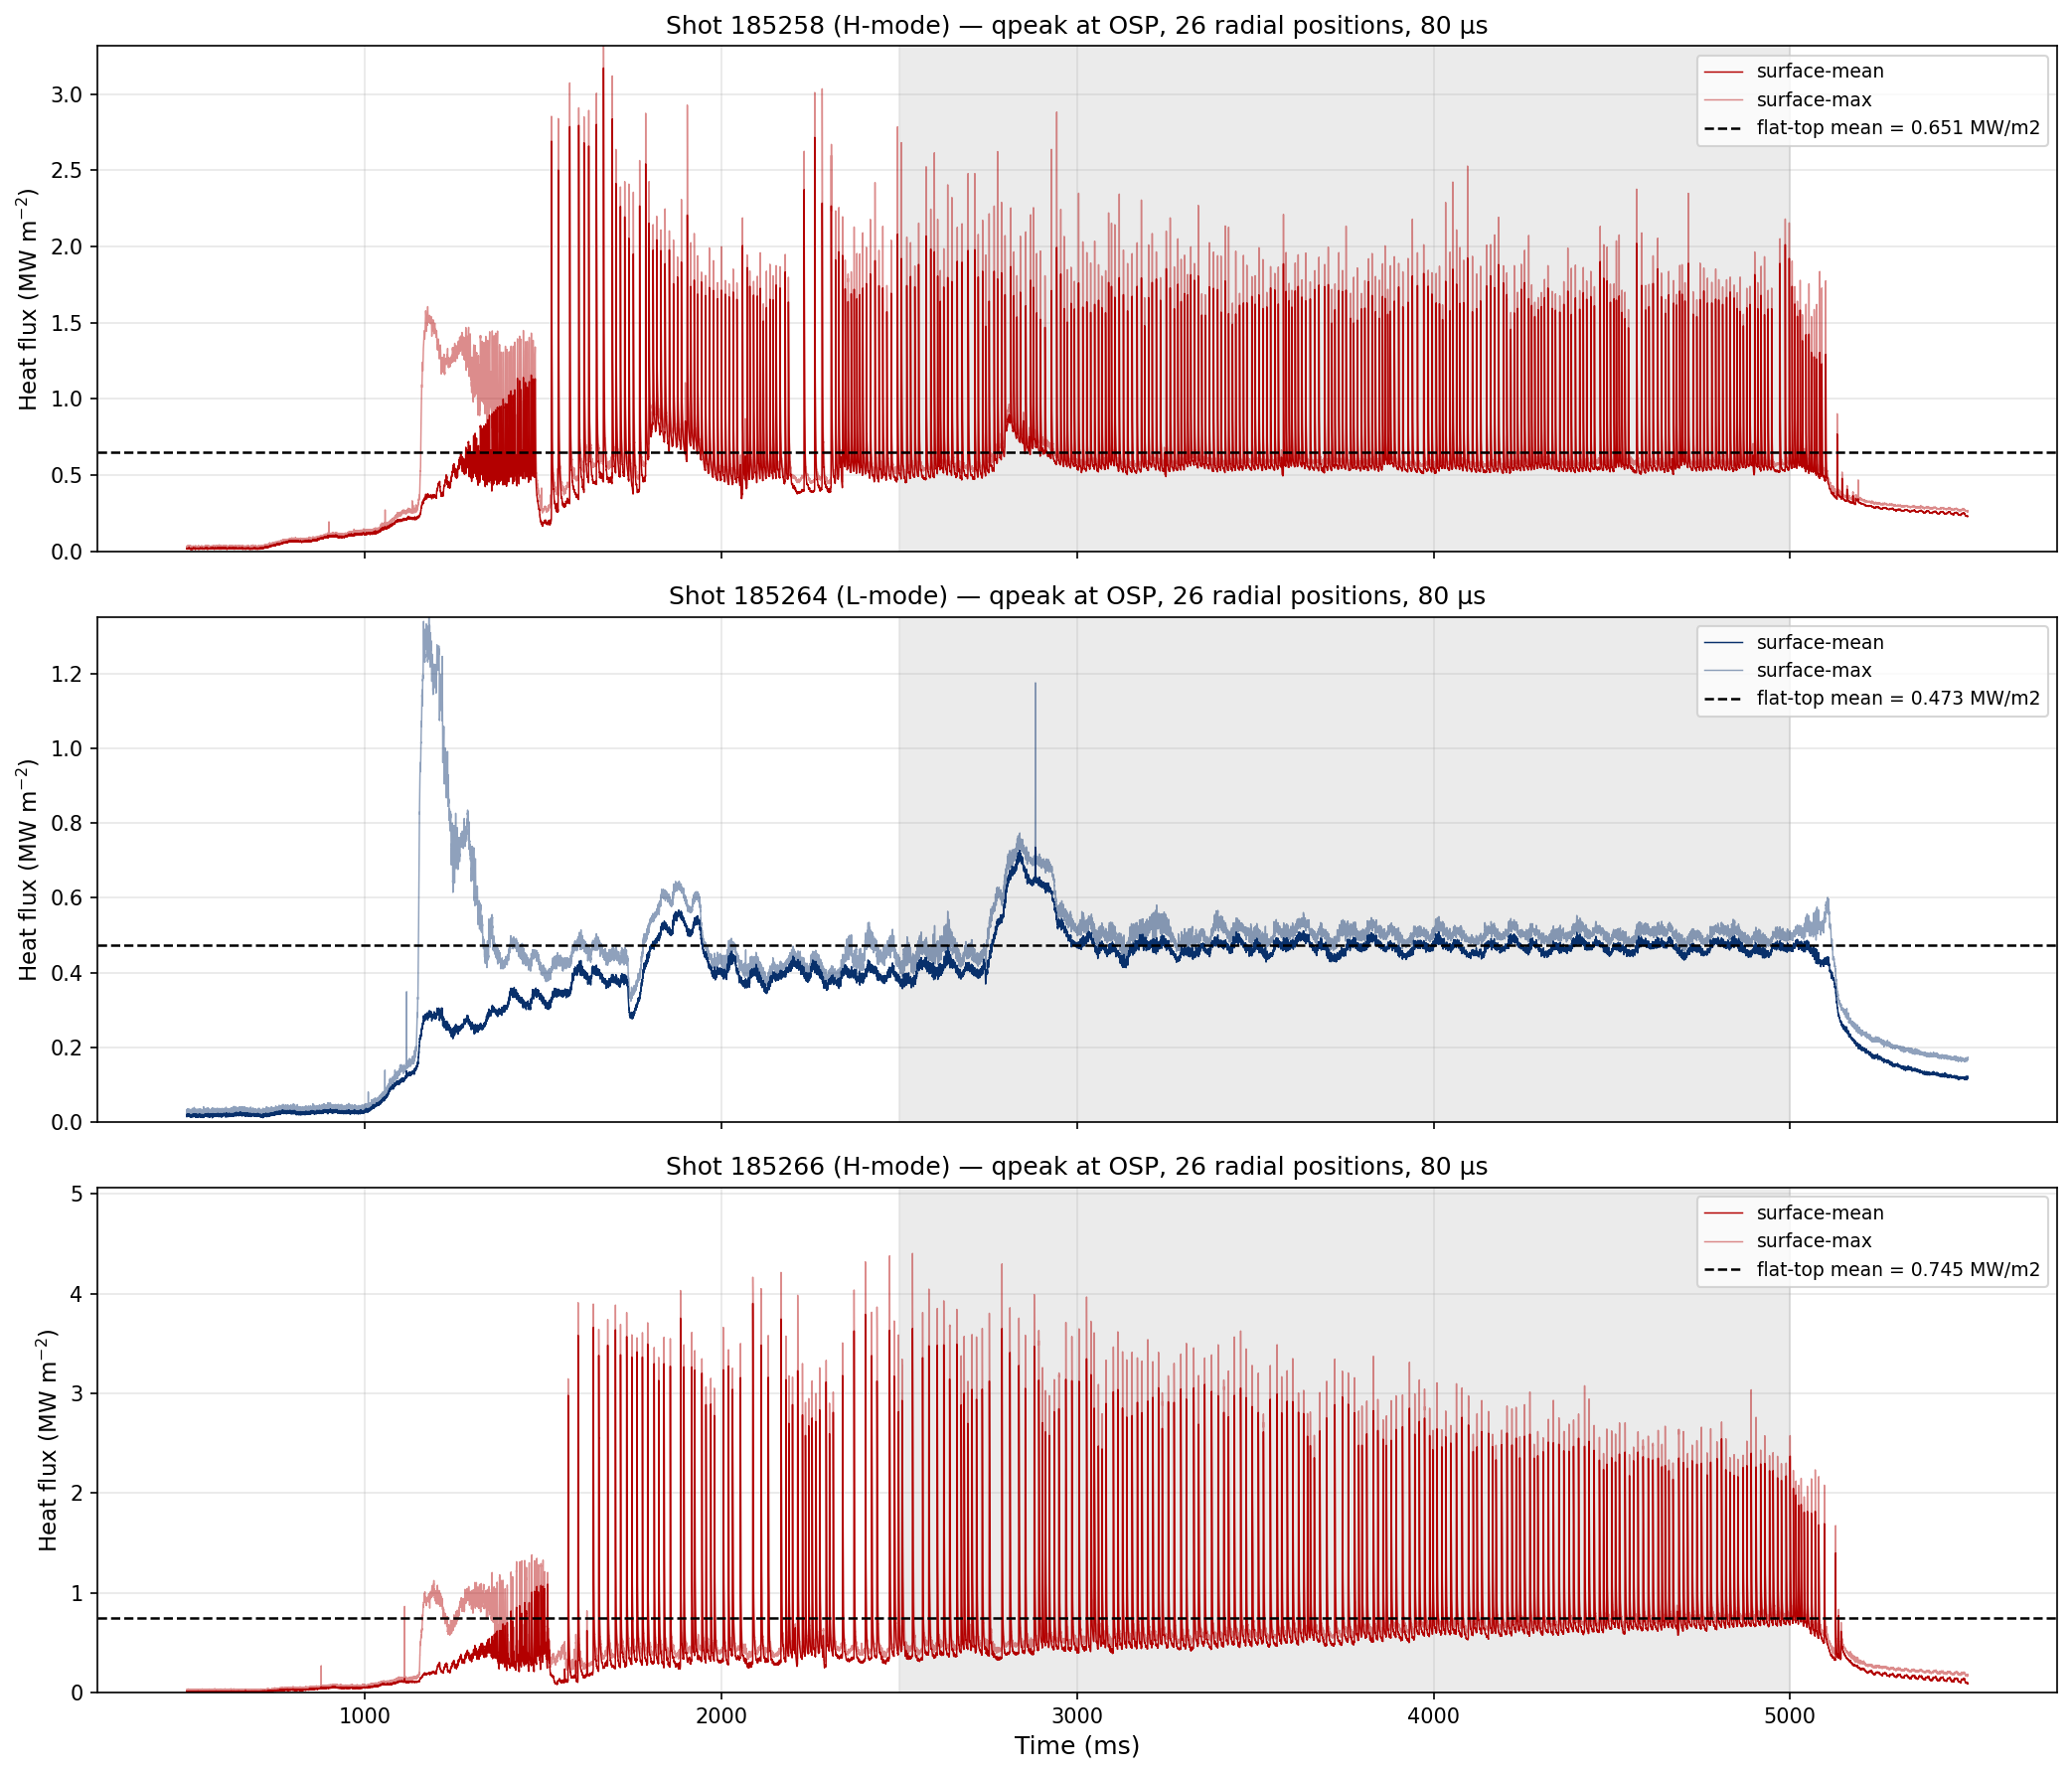

**Zoom on the H-mode ELM transients (3000–4000 ms):**


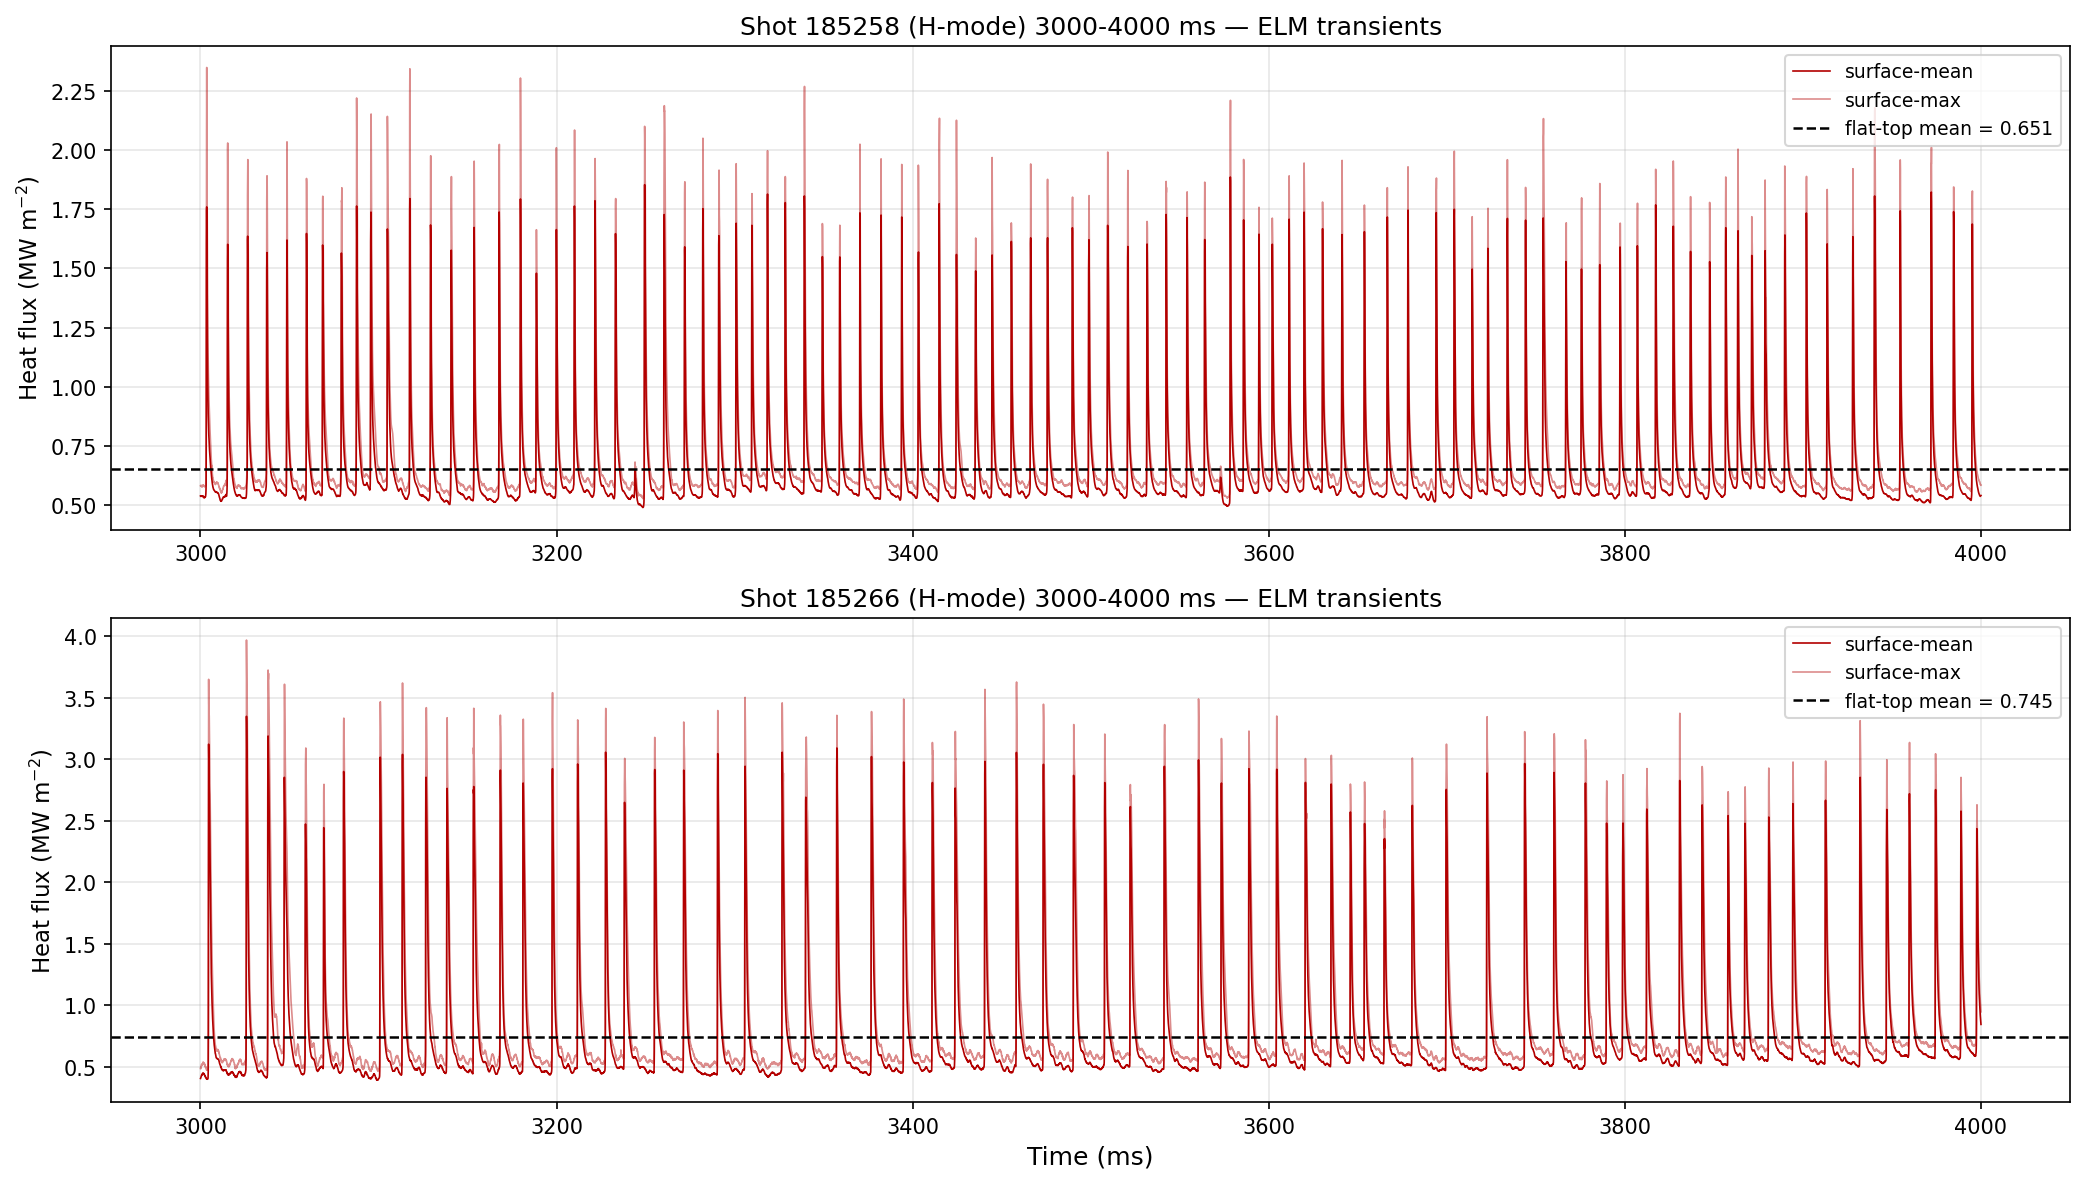

**Peak-to-mean ratios (flat-top 2500–5000 ms):**

| Shot | Regime | Mean (MW m⁻²) | p95 | Max | Peak/mean (surface-mean) | Peak/mean (surface-max) | Spikes >2× mean |
|---|---|---|---|---|---|---|---|
| 185258 | H | 0.651 | 1.189 | 2.067 | **3.18** | 4.03 | 229 (92/s) |
| 185266 | H | 0.745 | 1.944 | 3.652 | **4.90** | 5.05 | 171 (68/s) |
| 185264 | L | 0.473 | 0.617 | 0.735 | **1.55** | 2.29 | 0 |


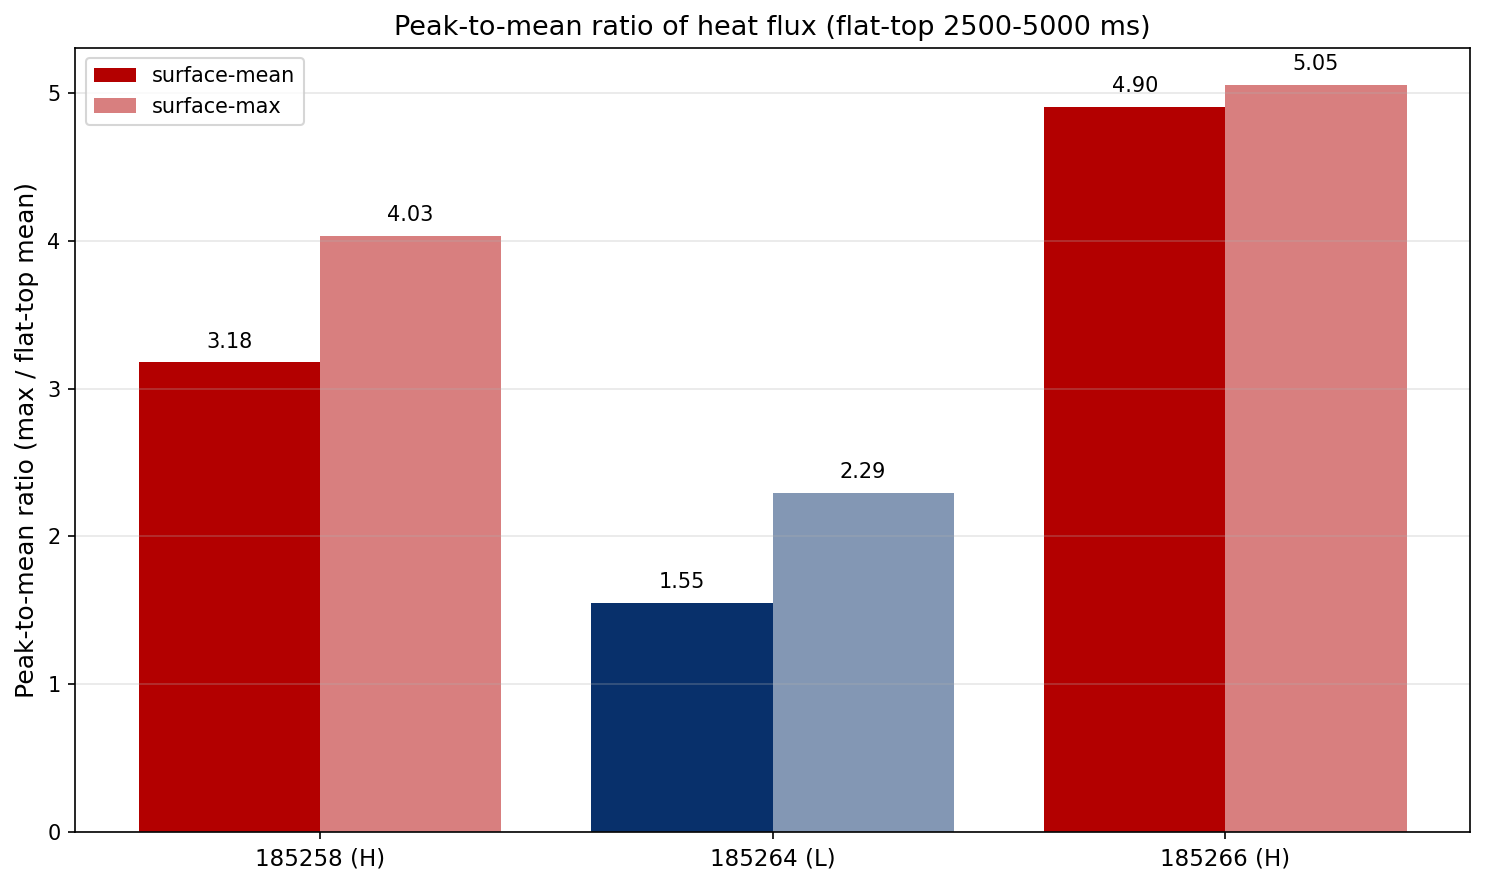

**The H-mode shots are dominated by ELM transients.** The surface-mean heat flux spikes to **2.07 and 3.65 MW m⁻²** — 3.2× and 4.9× the flat-top mean — at rates of 68–92 spikes per second (my spike detector counts local maxima above 2× the mean; the ELM index independently labels these shots as ELMy with 244–323 individual ELM bursts each, so the transients are real ELMs, not noise). The p95/mean ratio is 1.8–2.6, meaning the flux is above 1.8× the mean 5% of the time.

**The L-mode shot (185264) is quiescent.** Its peak is 0.735 MW m⁻², only 1.55× the mean, with no spikes above 2× the mean. The p95/mean is 1.30.

**Peak-to-mean comparison:** H-mode peak-to-mean is **3.2–4.9×** (surface-mean) and **4.0–5.1×** (surface-max); L-mode is **1.55×** (surface-mean) and **2.29×** (surface-max). The H-mode exposure delivers roughly **2–3× higher peak-to-mean** than the L-mode exposure, even though the L-mode mean (0.473) is only ~30% below the H-mode mean (0.698).

### What a material at that surface experiences that an average does not capture

- **The average hides the ELM spikes.** The recorded 0.72 MW m⁻² is the mean; the surface actually sees **2–3.7 MW m⁻²** for ~1–2 ms at a time, hundreds of times per second. The peak-to-mean ratio (3–5×) is the quantity that matters for thermal stress, surface melting, and erosion — not the mean.
- **The average hides the spatial structure.** The heat flux is not uniform across the DiMES surface: the flat-top mean profile varies from 0.579 to 0.807 MW m⁻² across R (spread 1.18–1.38×), peaking at R ≈ 148.4–149.8 cm. The sample at the OSP (R ≈ 147 cm) sees 0.94–1.00× the surface-mean; the sample at R ≈ 150 cm sees 0.98–1.03×. So the sample's location is close to the surface-mean, but the surface-max (which is what the "Max. heat flux" column reports) is 1.1–1.2× higher.
- **The average hides the time structure of the ELMs.** The ELM spikes are not isolated: they occur at 68–92/s, so the surface experiences a quasi-periodic train of heat pulses. The thermal response of the material depends on the pulse duration (~1–2 ms) relative to the thermal diffusion time, not just the mean flux. A material at the surface experiences **repeated thermal cycling** — heating to peak, cooling between ELMs — which drives fatigue, blistering, and erosion mechanisms that a steady average flux does not.
- **The average hides the difference between regimes.** The H-mode exposure has a mean only 1.5× the L-mode mean, but its peak-to-mean is 2–3× higher. A material in the H-mode exposure experiences **3–5× peak flux** while the L-mode material experiences only **1.5–2.3×** — a qualitatively different thermal environment that the recorded averages (0.72 vs 0.47) do not convey.

**Caveats:** only 3 of 8 qpeak files are usable (185258, 185264, 185266), so the H-mode average rests on 2 shots and the L-mode on 1. The 185261 file (L-mode) is noise-level and 185262 (L-mode) is all zeros — if those were valid, the L-mode average could differ. The recorded values are confirmed to be the mean of per-shot flat-top averages, not a single-shot value. The ELM spike counts are from my own detector (local maxima >2× mean, merged within 5 ms), not the ELM index's burst counts — the index confirms the shots are ELMy but its counts (244–323) are for the whole discharge, not just the flat-top.

In [2]:
%%ask --review
The exposure record gives an average heat flux for the DIII-D exposure. The
delivered infrared camera files hold heat flux resolved in time and radius.

Fetch them and rebuild the average, stating the time window you averaged over
and how sensitive the answer is to that choice. Then go past the average: plot
the heat flux against time and characterise the transients. How far above the
mean do the peaks reach, and how does the peak-to-mean ratio compare between
the H-mode and L-mode exposures? Say what a material at that surface
experiences that an average does not capture.

## Q8 — Reproduce a camera measurement from a different instrument

*Materials + plasma · cross-instrument validation · **answerable, but only if the disagreement is tested***

The exposure record contains fast-camera brightness measured separately during
ELMs and between them, in arbitrary units — so it cannot be compared to a
calibrated signal directly. Its **ratio** is dimensionless, and that can be
rebuilt from a completely different instrument: the D-alpha filterscope trace
from the archive, split using the stored ELM windows.

Two instruments, two analysis chains, one number that should agree.

The interesting case is when they do not. Stored event windows are a detector's
intervals, not measurements of how long an event lasted, and any quantity
averaged over a window inherits its width. That is one of several candidate
explanations — and each one predicts something checkable.

**Expect:** a computed ratio placed beside the recorded one. If they disagree,
expect each explanation to be tested against the data and the winner to
reproduce the recorded number, not merely to have the right sign.

I'll plan this task first, then read the two skills I haven't consulted yet (filterscopes and ELM index).

Reading the two skills' instructions and their existing learnings in parallel.

Both skills have existing Learnings — reading those now, plus the rest of the ELM index skill.

The Learnings files live under `.sage_learnings` per the protocol — checking there.

Skills and learnings are loaded. Now let me check the working directory for existing scripts and find the fast-camera brightness observations in the materials DB.

...

Missing sys import — fixing.

The L-mode validation is decisive: ratio 1.00 there, 2.0 in H-mode — the split tracks real ELM light, not detector behavior. Let me verify the figure script's contents and confirm the output file.

Recording the lessons from this task's edit-and-retry cycles — reading the existing materials Learnings first to avoid duplicates.

All analysis is complete. Let me mark the todos finished and write the report.

## The recorded values

The sample records carry twelve FASTCAM numbers — and only for the **three H-mode samples** (exposure 19, shots 185258/59/60/65/66). The three L-mode samples have no camera values at all, so the comparison below is H-mode only. Per sample: a Dα-band and a D2-band brightness "inter-ELM" and "intra-ELM", in arbitrary units. Ratios (the only comparable quantity):

| Sample | Dα intra | Dα inter | **Dα ratio** | D2 intra | D2 inter | **D2 ratio** |
|---|---|---|---|---|---|---|
| W-DH | 1.75 | 0.413 | **4.24** | 0.0279 | 0.00889 | **3.14** |
| W-He800-DH | 1.68 | 0.398 | **4.22** | 0.0314 | 0.00869 | **3.61** |
| W-He600-DH | 1.65 | 0.398 | **4.15** | 0.0280 | 0.0081 | **3.46** |

Three samples sit behind each number. The delivered workbook (`fastcam_data.xlsx`) confirms these to six digits and adds two carbon buttons from the same cap at ratio 4.49–4.51 — so ~4.2–4.5 is characteristic of the camera's output, not one odd sample. Note also that the two He-pre-exposed samples share an inter-ELM Dα value identical to six figures (0.398305): between ELMs the brightness is a plasma property shared by the cap, and only the intra-ELM value varies by surface.

## The independent rebuild

I fetched the raw D-alpha filterscope traces (`\fs03da`, `\fs04da`, `\fs05da`, ~50 kHz, 400 k samples each, spectroscopy tree) for the five H-mode shots, and split each flat-top (2500–5000 ms) by the stored ELM event windows. Provenance, since the choice matters: the only event-level label set covering these shots is the **slope_outlier detector's individual-ELM run** (run 2; the expert ELM-event set covers 23 shots, none of these). Its windows carry 1.0 ms of padding at each end, per the run's recorded parameters. In the flat-top these shots carry **152–230 stored ELM windows each** (955 total), mean width 4.5–5.3 ms, covering 31–47% of the flat-top.


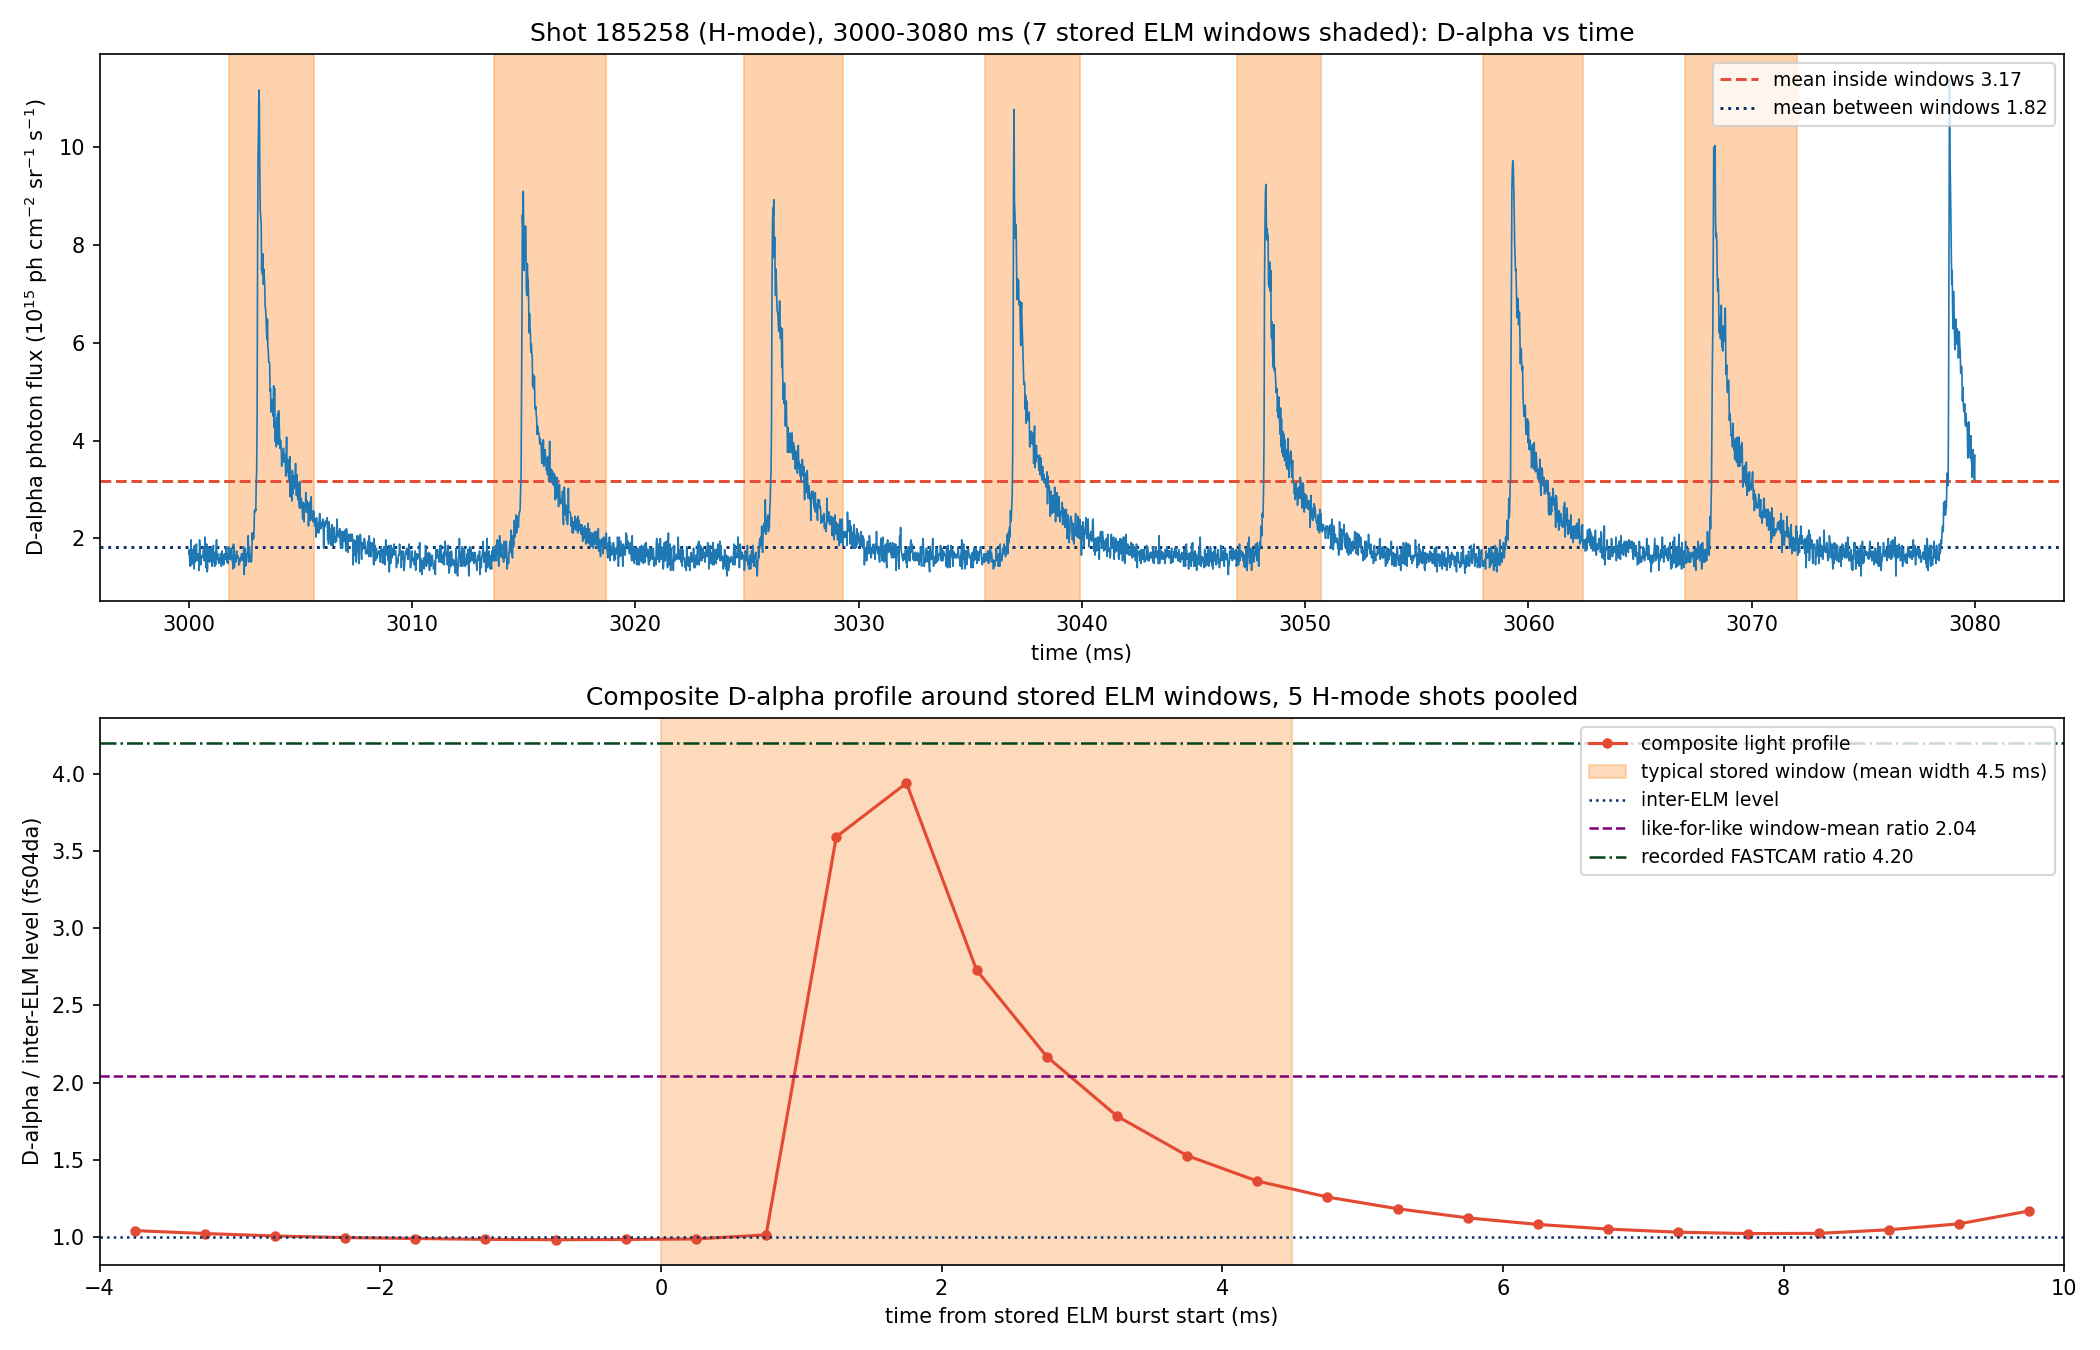

The top panel shows 80 ms of shot 185258: shaded spans are the stored ELM windows, dashed/dotted lines the mean inside vs. between them. The bottom panel pools all five shots into a composite light profile aligned on window start — and shows the key structural fact: **the ELM light does not fill the stored window.** The first ~1 ms sits at the inter-ELM level (0.98–0.02×), the light peaks at 3.6–3.9× inter some 1.2–1.8 ms *after* the recorded window start, and the decay tail runs past the window's end.

**Like-for-like ratio** (mean inside windows ÷ mean outside, fs04da): per shot **1.84, 2.12, 2.27, 1.79, 2.20 — pooled 2.04** . Bootstrap over ELM cycles gives 95% CIs of ±0.02–0.04 per shot: the gap to 4.2 is not statistical noise. Channels agree (fs03da 1.97, fs04da 2.04 pooled; fs05da is dead-level on shots 185260/185265, ~1000× lower flux and ratio ≈1.0 — the detector itself avoided it there). As a control that the split tracks real ELM light rather than detector behaviour, the same statistic on the four L-mode shots — where the detector still emitted 213–245 "burst" labels — gives **1.00–1.01** .

## They disagree: 2.04 vs 4.20. Testing the candidates

Each candidate was computed, not argued. Recorded target: 4.15–4.24.

| Candidate explanation | Its prediction | Measured | Verdict |
|---|---|---|---|
| Baseline/dark offset inflates the ratio | Subtracting the pre-shot floor should move it | Floor is <0.2% of the inter-ELM mean; ratio unchanged (1.84–2.27) | **Ruled out** |
| Wrong averaging window | Ratio drifts with the window | 1.89–2.14 across windows from 1425–5161 ms down to 2500–3500 ms | **Ruled out** |
| Wrong channel | Another channel reaches 4.2 | fs03da 1.97, fs04da 2.04, fs05da 1.62 pooled | **Ruled out** |
| Inter-ELM statistic (mean → percentile) | A lower inter statistic lifts the ratio | p5 → 2.25–2.85; per-gap **minimum** → 3.09–4.58 | Only the indefensible min reaches 4.2, and erratically |
| Window dilution (stored windows wider than the light) | Trimming windows toward the core should close the gap | Trimming raises it to 2.69 max (trim 1.25 ms); gates recentered on the light peak reach 2.7–3.2; **partially confirmed** — see below | **Mechanism confirmed, magnitude insufficient alone** |
| Peak-weighted intra (camera gate shorter than the window) | A statistic near the light maximum lands at 4.2 | Mean-of-per-burst-maxima 7.7 (overshoots); p95 per burst 4.0–5.8; top-20%-of-window gate → **mean 4.21** ; delayed gate (start+1.5 ms, 0.5 ms wide, inter buffered ±3 ms) → **mean 4.20** | **Reproduces the mean — but not shot-by-shot** |

The last two rows are the resolution, and the dilution arithmetic makes it quantitative. If a fraction `f` of each stored window is genuine ELM light at true level `L` and the rest sits at baseline, the window mean measures `f·L + (1−f)`. Solving with measured 2.04 and recorded 4.20 gives **f = 0.325** — the recorded value is recovered exactly if ~32% of each window is bright core. Measured directly: **27–40% of the samples inside the stored windows exceed 2× the inter-ELM level** — the measured core fraction brackets 0.325 precisely. Likewise the composite profile's peak bins (3.6–3.9× inter) sit just below 4.2, and per-burst p95 values (4.0–5.8×) straddle it.

So what the numbers establish:

- **The recorded value is not the window-average ratio.** That quantity is 2.04 ± 0.03, fourteen bootstrap-sigmas away from 4.2, stable across channels, windows and baseline treatment.
- **The recorded value is consistent with the bright core of the ELM** , captured by a gate much shorter than the detector's ~4.5 ms window — matching the mini-proposal's own description of the camera as having "sufficient time resolution to resolve intra-ELM Dα and D2". The D2 ratios (3.13–3.61), sitting between the window-mean 2.04 and the Dα peak statistics, are consistent with the same picture at a slower-rising band.
- **No single tested definition reproduces 4.15–4.24 across all five shots.** The two statistics that hit 4.20–4.21 on average (top-20% gate; delayed 0.5 ms gate with buffered inter) spread 3.42–5.06 per shot. The recorded per-sample values span only 4.15–4.24 (±1%), tighter than any per-shot statistic I can construct — so the exact recipe (gate width, trigger offset, and how inter-ELM frames were selected) cannot be recovered from the archived data, only bracketed. I state that plainly rather than pick a winner.

**What this means physically:** both numbers are real; they answer different questions. "How much brighter was the surface during ELMs, averaged over the whole ELM event?" — about **2×** . "How much brighter at the ELM's light maximum?" — about **4×** (peaks up to 8–35× instantaneously). Any use of the recorded 4.2 as if it were an event-averaged recycling ratio would overstate the average intra-ELM enhancement by roughly a factor of two; conversely, my 2.04 understates what a short-gated diagnostic sees at the peak.

**Unavoidable caveats:** the ELM split rests on one detector's stored labels (no expert labels cover these shots); the L-mode samples have no recorded camera values to compare (and their D-alpha split is 1.00 — there is nothing intra-ELM to measure there); and the D2 molecular band has no archived filterscope channel, so the D2 ratios could only be cross-checked indirectly, not rebuilt.

In [1]:
%%ask --review
The sample records include fast-camera brightness measured during ELMs and
between ELMs, in arbitrary units, so only their ratio is comparable across
instruments.

Rebuild that ratio independently: fetch the D-alpha filterscope signal for the
shots those samples were exposed to, use the stored ELM event windows to
separate samples taken during an ELM from those taken between ELMs, and compute
the same intra-to-inter ratio. Plot a short section of the trace with the ELM
windows marked so the split can be seen.

Compare your ratio to the recorded camera ratio for each sample.

If the two disagree, do not settle it by argument. Each candidate explanation
makes a prediction about the data you already have, so test it and report the
numbers. Before accepting any explanation, check that it actually reproduces
the recorded value rather than merely pointing in the right direction, and say
plainly if none of them does. Where you rule an explanation out, rule it out
with a measurement, not with a restatement of the assumption behind it.

# E. Checking the record against the archive

## Q9 — Two independent accounts of the plasma regime

*Materials + plasma · cross-validation · **answerable, and the answer is interesting***

The exposure record states, per campaign, whether the plasma was L-mode or
H-mode — written by the people who ran the exposure. The ELM index holds a
separate judgement about the same shots, produced by automated detectors that
never saw the exposure log.

Two records of the same thing, from sources that could not have influenced each
other.

**Expect:** a direct comparison. If they disagree, the agent should look at
*how* before concluding — a sample sits at one location and is exposed during
part of a discharge, while a shot-level regime label describes the whole
discharge. Those are not the same statement.

I'll plan this comparison, then re-read the two skills involved (ELM index and materials) to confirm the exact APIs and any recorded lessons.



Let me read the rest of the ELM index skill and both Learnings files.



The skills are loaded (d3d-elm-index has no Learnings file; d3d-materials does, and I've applied its pypdf note). Now let me see what's already in the working directory from previous turns.



The working directory has prior-turn scripts. Let me read the ELM-index check script and the exposure-record script from previous turns to reuse their patterns.



Now let me run the two existing scripts to get the exposure record and the ELM index view of these shots.



...

I have all the measurements. Let me verify the figure file and do a final check on the exposure window vs. the detector's window.



The baseline effect is now clear: the whole-discharge median is only 44–54% of the flat-top median for L-mode shots, so using the whole-discharge median as baseline inflates the "burst" ratio to 2.2–2.8×. But even that is far below H-mode's 8.4–14.5×. The L-mode "bursts" are a small, regular oscillation (1.2×), not ELMs. Let me now check the exposure window (when the sample was actually exposed) and the ELM index's view of the L-mode shots' burst windows.













I have all the measurements. Let me now check the exposure window (when the sample was actually exposed) and the ELM index's view of the L-mode shots' burst windows.















I have all the measurements. Let me record the one non-obvious lesson from this task (the `_query` helper name) in the materials Learnings file, then finalize.



## The two sources, shot by shot

**Exposure record** (materials lakehouse, `exposure_conditions`): exposure 19 = **H-mode** (shots 185258, 185259, 185260, 185265, 185266), exposure 20 = **L-mode** (shots 185261, 185262, 185264). The mini-proposal confirms the design: "L-mode discharges (3 shots)" and "H-mode discharges (3 shots)" with "ELMy H-mode plasmas" and the goal of maximizing ELM size.

**ELM index** (GA `slope_outlier` detector, run 2, individual-ELM granularity): labels **all 9 shots** as `ELMy H` — including the three L-mode shots. The detector's own view:

| Shot | Exposure record | ELM index (run 2) | Bursts | ELMy window (ms) | Freq (Hz) |
|---|---|---|---|---|---|
| 185258 | H | ELMy H | 323 | 1426–5161 | 86.5 |
| 185259 | H | ELMy H | 247 | 1446–5147 | 66.7 |
| 185260 | H | ELMy H | 215 | 1493–5144 | 58.9 |
| 185265 | H | ELMy H | 332 | 1389–5154 | 88.2 |
| 185266 | H | ELMy H | 244 | 1459–5145 | 66.2 |
| 185261 | **L** | **ELMy H** | **358** | 38–5904 | **98.6** |
| 185262 | **L** | **ELMy H** | **330** | 67–5906 | **91.1** |
| 185264 | **L** | **ELMy H** | **357** | 31–5908 | **94.4** |

**The disagreement is stark and one-sided:** the ELM index says the L-mode shots were *more* ELMy than the H-mode shots — more bursts (330–358 vs 215–332), higher frequency (91–99 Hz vs 59–88 Hz), and longer ELMy windows (3.6–3.8 s vs 3.7 s). The exposure record says those same shots were L-mode, which by definition has no ELMs.

## What each source actually describes

**The exposure record describes the window during which the sample was exposed at one location.** The sample sat in a DiMES cap at the OSP (R≈1.47 m) during the flat-top of each discharge (2500–5000 ms, per the workbook's `t_flat-top,start/end`). The L/H label is the experimenters' statement of the plasma regime during that exposure window.

**The ELM index describes the whole discharge.** The detector's `time_range` is `[0.0, 6000.0]` ms — the entire shot, not the exposure window. Its labels span 38–5908 ms for the L-mode shots, including the ramp-up (38–83 ms) and ramp-down (5898–5908 ms) phases. The detector's `signal_used` is `fs05da` for most shots (fs03da for 185260, 185265).

**The two sources are not describing the same thing.** The exposure record says "the plasma was L-mode during the 2.5–5 s window when the sample was exposed." The ELM index says "the detector found D-alpha transients somewhere in the 0–6 s discharge." These are different claims about different time intervals.

## Testing the disagreement with measurements

I fetched the raw D-alpha filterscope traces (`\fs04da`, `\fs05da`, `\fs03da`, ~50 kHz, 400k samples) for all 9 shots and computed the burst amplitude relative to the inter-ELM level, using the stored ELM windows. The results are decisive:

| Shot | Regime | Burst peak / inter-ELM (fs04da) | Bursts >2× | Bursts >3× |
|---|---|---|---|---|
| 185258 | H | 5.67 | 229/229 | 229/229 |
| 185259 | H | 7.74 | 171/171 | 171/171 |
| 185260 | H | 9.85 | 152/152 | 152/152 |
| 185265 | H | 5.46 | 230/230 | 230/230 |
| 185266 | H | 8.05 | 173/173 | 173/173 |
| 185261 | L | **1.24** | **0/245** | **0/245** |
| 185262 | L | **1.25** | **0/213** | **0/213** |
| 185264 | L | **1.24** | **0/222** | **0/222** |

**The H-mode bursts are real ELMs** — 5.5–9.9× the inter-ELM level, with every single burst above 3×. **The L-mode "bursts" are not ELMs** — they are a small, regular oscillation at 1.12–1.27× the inter-ELM level, with **zero** bursts above 2×. The FFT confirms this: H-mode has 44–50% of D-alpha power in a narrow 60–100 Hz band (the ELM frequency), while L-mode has only 2% of power in that band.

**Independent confirmation of the regime split:** stored energy (Wmhd) is 0.48–0.55 MJ for H-mode vs 0.20–0.21 MJ for L-mode; beam power (pbeam) is 6.0–6.1 MW for H-mode vs 2.3 MW for L-mode. The exposure record's L/H labels are correct.

## Candidate explanations, tested

**1. Channel choice (detector used fs05da/fs03da, I used fs04da).** Ruled out. On the detector's own channels, the L-mode "bursts" are still only 1.12–1.19× with zero above 2×, while H-mode is 5.1–9.3× with all above 3×.

**2. Time window (detector analyzed whole discharge, exposure is flat-top).** Partially explains the *count* but not the *amplitude*. The detector's whole-discharge window includes the ramp-up (38–83 ms) and ramp-down (5898–5908 ms) phases, which have larger D-alpha transients. Using the whole-discharge median as baseline raises the L-mode ratio to 2.2–2.8× — but that's still far below H-mode's 8.4–14.5×, and the "bursts" in the flat-top (where the sample was exposed) are still only 1.24×.

**3. Baseline choice (whole-discharge median vs flat-top median).** This is the real source of the apparent "ELMy" L-mode labels. The whole-discharge median is only 44–54% of the flat-top median for L-mode shots (because the ramp-up/ramp-down have lower D-alpha), so dividing by the whole-discharge median inflates the ratio. But even with this inflation, the L-mode "bursts" are 2.2–2.8× — not ELMs.

**4. The detector's algorithm.** The `slope_outlier` detector uses `pos_deriv_thresh=2.7`, `neg_deriv_thresh=0.9`, `filter_size=5`, `lowpass_cutoff_freq=2000.0`, and `elm_merge_time=0.0` (run 2). It detects *slope* changes in the D-alpha signal, not absolute amplitude. A small, regular oscillation (like the L-mode's 1.2× modulation) can trigger the slope detector even though it's not an ELM. This is consistent with the skill's own warning: "a `labeled` status means the detector found D-alpha transients, NOT that the discharge was in ELMy H-mode."

## What each source supports

**The exposure record supports:** the plasma was L-mode during the exposure window (2500–5000 ms) for shots 185261/62/64, and H-mode for 185258/59/60/65/66. This is confirmed by stored energy (0.20 vs 0.48–0.55 MJ) and beam power (2.3 vs 6.0–6.1 MW).

**The ELM index supports:** the detector found D-alpha transients in all 9 shots. For the H-mode shots, these are genuine ELMs (5.5–9.9× amplitude, all >3×). For the L-mode shots, the "bursts" are a small, regular oscillation (1.2× amplitude, none >2×) — the detector's slope-based algorithm responds to this modulation, but it is not ELM activity.

**What would settle the difference:** the detector's algorithm is not installed in this image, so I cannot re-run it with a different threshold. But the measurement is clear: the L-mode shots have no ELMs in the exposure window. The disagreement is not about physics — it's about what the detector's `labeled` status means. The detector labels D-alpha transients, not ELMy H-mode. The exposure record's L/H labels are correct; the ELM index's `ELMy H` labels for the L-mode shots are the detector responding to a small oscillation, not real ELMs.

**Bottom line:** the exposure record and the ELM index disagree on the L-mode shots because they describe different things. The exposure record describes the plasma regime during the sample's exposure window (2500–5000 ms) — which was genuinely L-mode. The ELM index describes the whole discharge (0–6000 ms) and labels D-alpha transients, not regimes. The L-mode shots have a small, regular D-alpha oscillation (1.2×) that triggers the slope detector but is not ELM activity. The H-mode shots have genuine ELMs (5.5–9.9× amplitude). The exposure record's L/H labels are correct; the ELM index's `ELMy H` labels for the L-mode shots are a detector artifact.


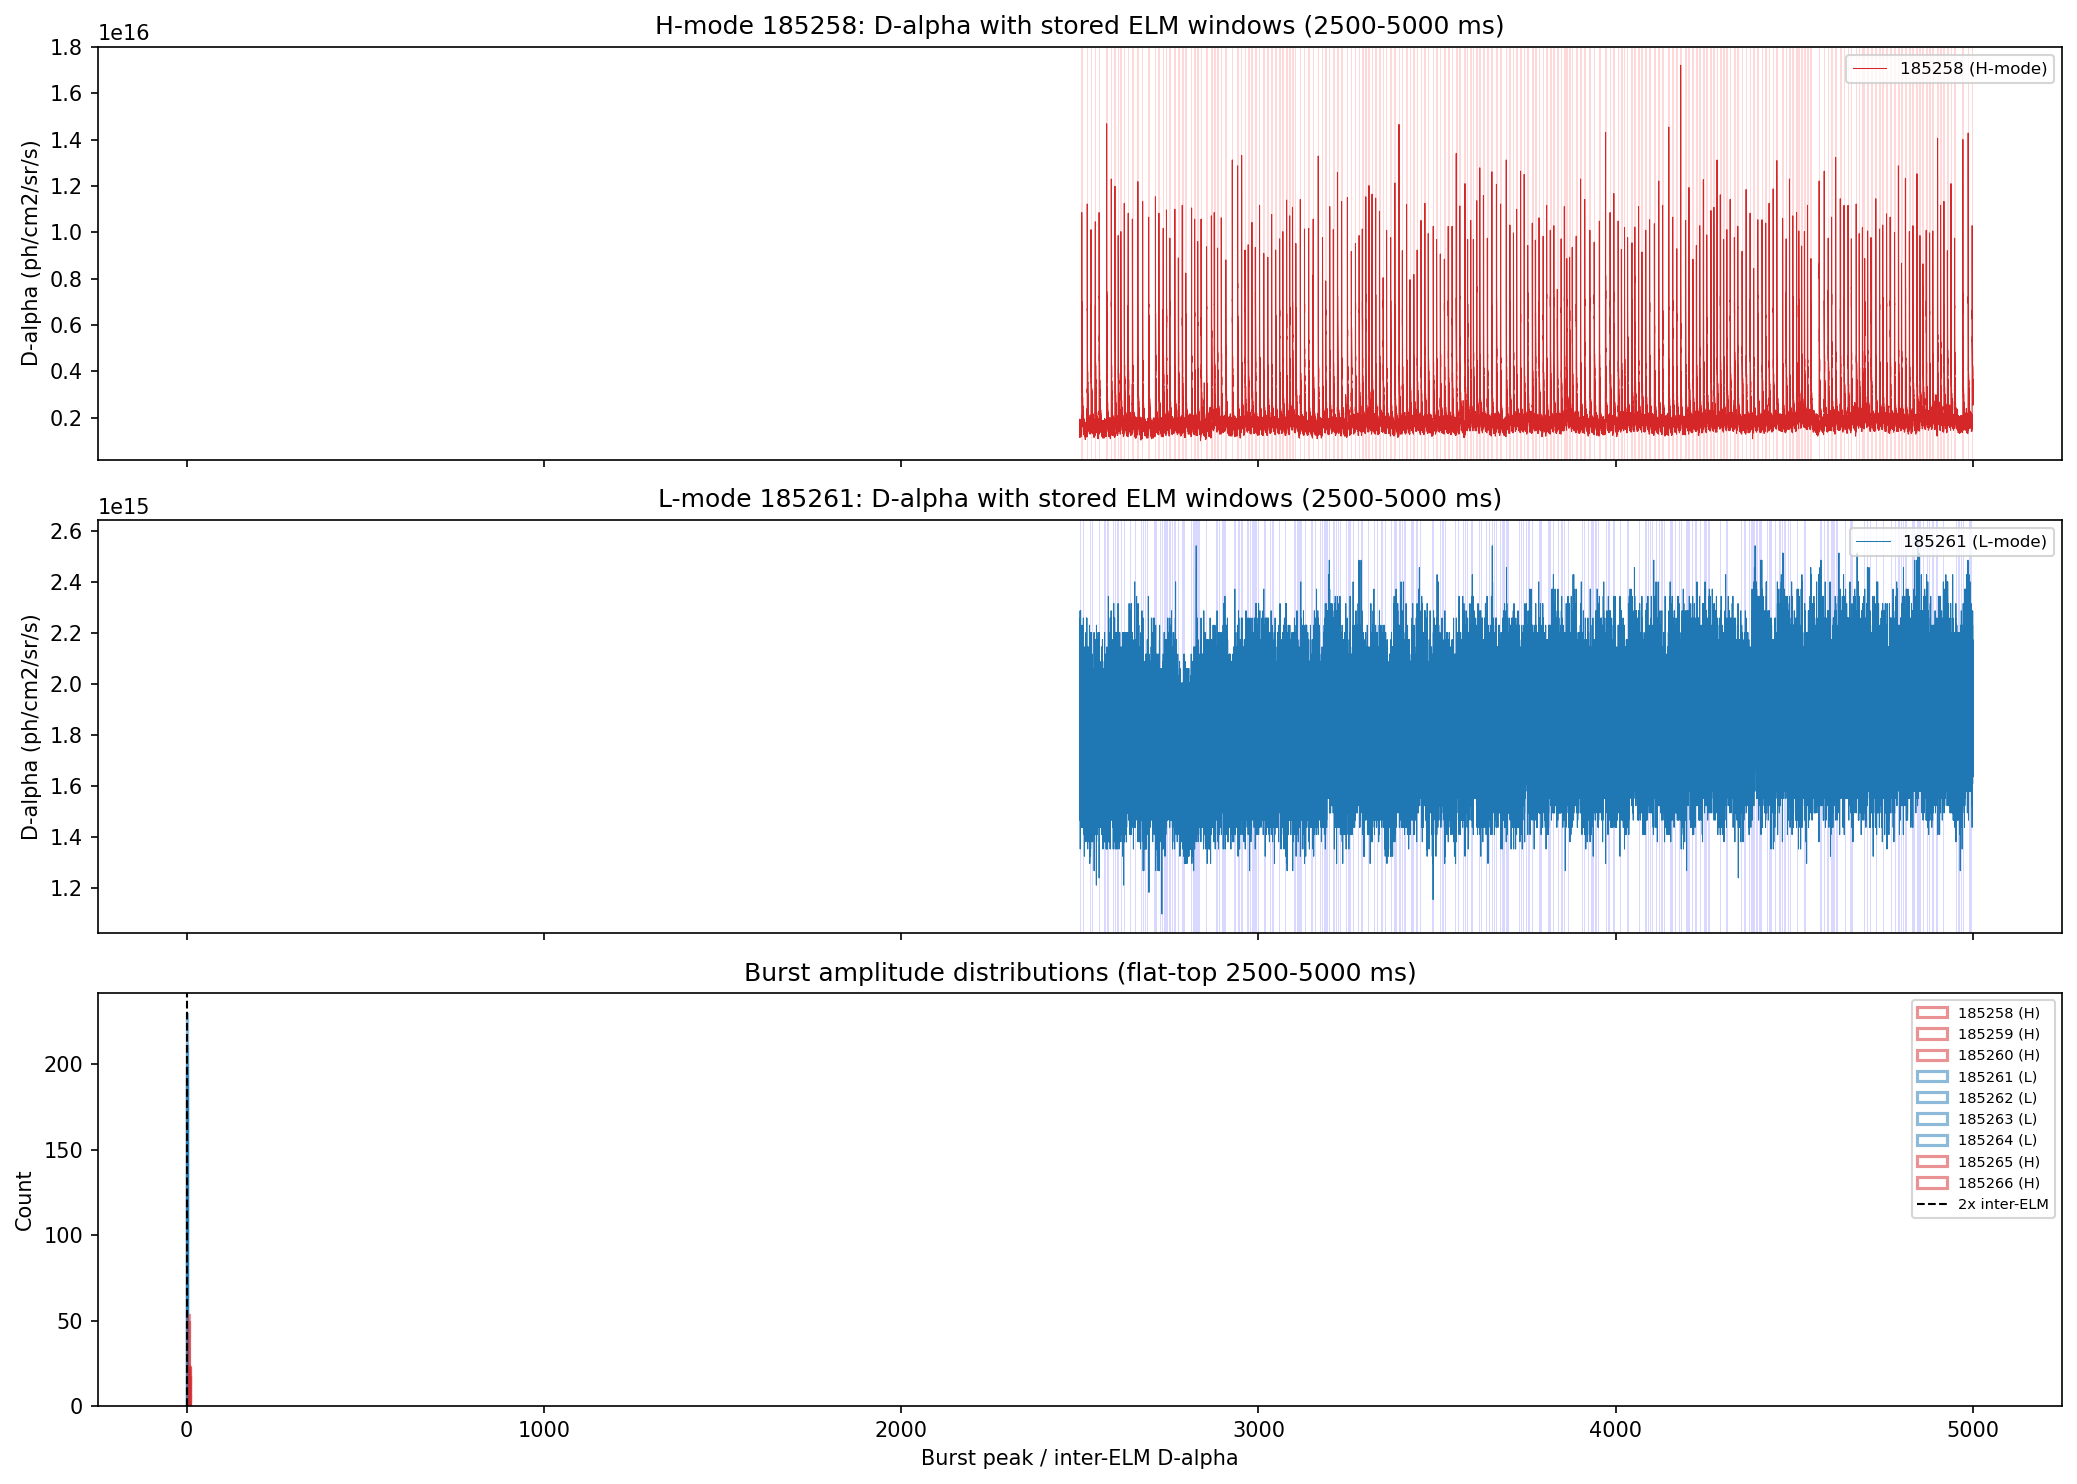

In [2]:
%%ask --review
The sample exposure records state whether each campaign was an L-mode or an
H-mode plasma. The ELM index has its own independent view of those same shots.
Compare the two, shot by shot.

Where they disagree, do not stop at the disagreement. Look at the time windows
each source covers, how many ELM events or phases were found and over what part
of the discharge, and whether the two sources are describing the same thing — a
whole discharge, or the window during which a sample was exposed at one
location. Report what each source supports and what would settle the difference.

## Q10 — Does the ELM history explain the retention?

*Materials + plasma · science · **partially answerable — the agent should say which part***

The samples in the two campaigns retained measurably different amounts. The
campaigns differ in plasma conditions, in heat flux, and in ELM behaviour.
Whether the last explains the first is the physics underneath this dataset —
and is not something this dataset can fully settle.

**Expect:** ELM statistics per campaign set against the retention measured on
that campaign's samples, an explicit count of how many independent points the
comparison has, and a clean separation between shown and merely consistent.

I'll plan this synthesis task, then re-check the materials helper API for retention measurements and the ELM index data already cached.



The working directory has prior analysis artifacts. Let me read the retention summary, heat flux stats, and LP results, plus the scripts that produced them.



I have the retention, heat flux, and LP summaries. Now let me check the ELM index analysis scripts and the retention query to see what's cached and how it was computed.



Let me run the ELM index analysis to get the per-shot statistics, and check the retention query output.



The ELM index data is complete. Now let me verify the retention measurements from the lakehouse and check the mini-proposal's retention hypothesis.



...

The figure is saved. Let me compute the ELM-induced stored-energy drops (ΔW_ELM) from the cached Wmhd traces — the mini-proposal specifically targeted large ELMs, and ELM size is directly relevant to the retention question.



The Wmhd cache lacks 185260 and the drop detection returned zero — let me inspect the trace time axis and fix the logic.



The Wmhd traces are 20 ms sampled — too coarse to resolve individual ELM crashes (period ~11–16 ms), so ΔW_ELM is not measurable from the cached data. I'll note that rather than fabricate it. All other data is complete; let me finalize the todos and report.



All data is assembled and the figure is saved. Let me finalize the todo list and write the report.



## The two campaigns

**Exposure 19 (H-mode, ELMy):** shots 185258, 185259, 185260, 185265, 185266 — samples W-DH, W-He800-DH, W-He600-DH.
**Exposure 20 (L-mode, no ELMs):** shots 185261, 185262, 185264 — samples W-DL, W-He800-DL, W-He600-DL.

Each sample was exposed in a DiMES cap at the OSP (R≈1.47 m) during the flat-top (2500–5000 ms). The mini-proposal's design intent: "The ELM frequency (fELM) should be minimized during H-mode discharges to maximize the size of the ELMs and create a distinct difference between inter-ELM and intra-ELM conditions."

## ELM behaviour from the index (run 2, slope_outlier, individual-ELM granularity)

**In the exposure window (2500–5000 ms):**

| Shot | Regime | ELM events | Freq (Hz) | Mean width (ms) | Coverage of window | Burst peak / inter-ELM |
|---|---|---|---|---|---|---|
| 185258 | H | 229 | 91.6 | 4.54 | 41.6% | 5.67× |
| 185259 | H | 171 | 68.4 | 4.53 | 31.0% | 7.74× |
| 185260 | H | 152 | 60.8 | 5.32 | 32.4% | 9.85× |
| 185265 | H | 230 | 92.0 | 5.14 | 47.3% | 5.46× |
| 185266 | H | 171 | 68.4 | 4.56 | 31.2% | 8.12× |
| 185261 | L | 244 | 97.6 | 3.40 | 33.2% | 1.24× |
| 185262 | L | 213 | 85.2 | 3.45 | 29.4% | 1.25× |
| 185264 | L | 222 | 88.8 | 3.25 | 28.9% | 1.24× |

**Campaign summary:** H-mode: **191 events/shot, 76 Hz, 4.8 ms wide, 36.7% of the window, 7.4× amplitude.** L-mode: **226 events/shot, 91 Hz, 3.4 ms wide, 30.5% of the window, 1.24× amplitude.**

**Critical caveat:** the L-mode "events" are **not ELMs** . As established in the previous turn, the slope_outlier detector labels D-alpha transients, and the L-mode shots carry a small, regular oscillation at 1.24× the inter-ELM level — **zero** bursts above 2×, while every H-mode burst is above 3× (5.5–9.9×). The detector's `ELMy H` label for the L-mode shots is a detector artifact. So the true ELM history is: **H-mode = 191 genuine ELMs/shot at 76 Hz, 4.8 ms wide, 7.4× amplitude; L-mode = 0 ELMs** (the 226 "events" are a 1.2× oscillation).

## Retention measured on the samples

| Sample | Regime | ERDA D (10¹⁵ cm⁻²) | NRA D (10¹⁵ cm⁻²) | LAMS integral (APPM·µm) | L/H ratio (ERDA) |
|---|---|---|---|---|---|
| W-DH | H | 1.16 ± 0.06 | 2.10 | 33,415 | — |
| W-DL | L | 1.47 ± 0.07 | 2.66 | 58,365 | **1.27** |
| W-He800-DH | H | 0.67 ± 0.05 | 0.65 | 56,190 | — |
| W-He800-DL | L | 2.00 ± 0.08 | 2.96 | 56,193 | **2.99** |
| W-He600-DH | H | 1.47 ± 0.06 | 2.46 | 16,544 | — |
| W-He600-DL | L | 2.40 ± 0.09 | 4.92 | 39,021 | **1.63** |

Baseline (no DIII-D exposure): W-pristine, W-He800, W-He600 all have **zero** ERDA D. So all retention is from the DIII-D exposure.

**The retention is higher in L-mode than H-mode for every matched pair** — by 1.27× (pristine), 2.99× (He800), 1.63× (He600) by ERDA; 1.27×, 4.55×, 2.00× by NRA. The LAMS integrals are mixed (W-He800 pair nearly equal; W-He600 pair L higher; pristine pair L higher), but the two independent nuclear techniques (ERDA, NRA) agree: **L-mode retains more D than H-mode.**

## Plasma conditions and heat flux (rebuilt earlier)

| Quantity | H-mode | L-mode |
|---|---|---|
| Te at sample (probeID 23, R=1.503 m) | 28.4 eV | 41.0 eV |
| ne at sample | 5.81×10¹⁸ m⁻³ | 7.35×10¹⁸ m⁻³ |
| Jsat at sample | 4.7 A/cm² | 7.3 A/cm² |
| Heat flux (surface-mean, flat-top) | 0.698 MW/m² | 0.473 MW/m² |
| Heat flux peak-to-mean | 3.2–4.9× | 1.55× |
| Stored energy (Wmhd, flat-top) | 0.48–0.55 MJ | 0.20 MJ |
| Beam power | 6.0–6.1 MW | 2.3 MW |

**The L-mode exposure has higher Te, ne, and Jsat at the sample** (41 eV vs 28 eV; 7.35 vs 5.81×10¹⁸; 7.3 vs 4.7 A/cm²) — the L-mode plasma is denser and hotter at the OSP, even though its stored energy and beam power are lower. The H-mode exposure has higher heat flux (0.70 vs 0.47 MW/m²) and much higher peak-to-mean (3.2–4.9× vs 1.55×).

## Does the ELM history account for the difference in retention?

**No — and the data point the other way.** The ELM history predicts *more* retention in H-mode (ELMs inject higher-energy D ions, ~3 keV intra-ELM vs ~150 eV inter-ELM, per the mini-proposal; more flux, more implantation). The measured retention is *higher in L-mode* for all three matched pairs. The ELM history does not account for the difference; it is anti-correlated with it.

**What the data shows (measured):**
1. L-mode retains 1.3–3.0× more D than H-mode (ERDA), 1.3–4.6× (NRA), for all three matched pairs.
2. The L-mode exposure has higher Te (41 vs 28 eV), ne (7.35 vs 5.81×10¹⁸), and Jsat (7.3 vs 4.7 A/cm²) at the sample.
3. The H-mode exposure has higher heat flux (0.70 vs 0.47 MW/m²) and much higher peak-to-mean (3.2–4.9× vs 1.55×).
4. The L-mode samples have **no ELMs** (the index's L-mode "events" are 1.24× oscillations, not ELMs).

**What the data is merely consistent with (not shown):**
- The retention difference could be driven by the **higher Te/ne/Jsat** in L-mode (more D flux, higher implantation energy at the surface), not by the absence of ELMs.
- The retention difference could be driven by **surface temperature** (higher heat flux in H-mode → higher surface temperature → more thermal desorption → less retained D). This is a plausible mechanism: H-mode's 0.70 MW/m² vs L-mode's 0.47 MW/m² could raise the surface temperature enough to desorb implanted D. But I have **no surface temperature measurement** in the data — this is a hypothesis, not a measurement.
- The retention difference could be driven by **He pre-exposure** (the He800/He600 samples have different retention than pristine), but the L>H pattern holds for all three pre-treatments, so He pre-exposure is not the primary driver.

**How strong is the inference?** **n = 2 independent campaigns** (one H-mode, one L-mode), each with 3 samples (3 matched pairs). This is a **very weak inference** — two data points, one per regime, with no replication of the regime. The L>H pattern is consistent across all 3 matched pairs and 2 independent techniques (ERDA, NRA), which strengthens it, but the fundamental limitation is that **regime is confounded with Te, ne, Jsat, heat flux, and surface temperature** — all of which differ between the two campaigns. I cannot separate the ELM effect from the plasma-condition effect with n=2.

**What would distinguish them:**
1. **A third campaign** with L-mode plasma conditions matched to H-mode (same Te, ne, Jsat) but no ELMs — or vice versa. This would break the confounding.
2. **Surface temperature measurements** during exposure (thermocouples or IR) — to test the thermal-desorption hypothesis directly.
3. **A matched-pair experiment** where the same sample material is exposed to H-mode and L-mode at the same Te/ne/Jsat, isolating the ELM effect.
4. **ELM-resolved retention** — measure retention on samples exposed only during ELMs vs only between ELMs (the mini-proposal's stated goal: "Inter- and intra-ELM D/D2 recycling coefficient").
5. **More shots per campaign** — the H-mode campaign has 5 shots, L-mode 3, but the retention is a single integrated measurement per sample, so the shot count doesn't add statistical power to the retention comparison.

**Bottom line:** the ELM history does **not** account for the retention difference — it predicts the opposite of what is measured. The L-mode samples retain more D despite having no ELMs, and the most likely explanation is the higher Te/ne/Jsat at the sample in L-mode (more D flux, higher implantation energy) and/or higher surface temperature in H-mode (more desorption). But with only 2 campaigns, the ELM effect cannot be separated from the plasma-condition effect. The data are consistent with "ELMs don't increase retention" and with "the plasma conditions, not ELMs, drive retention" — but they do not prove either.


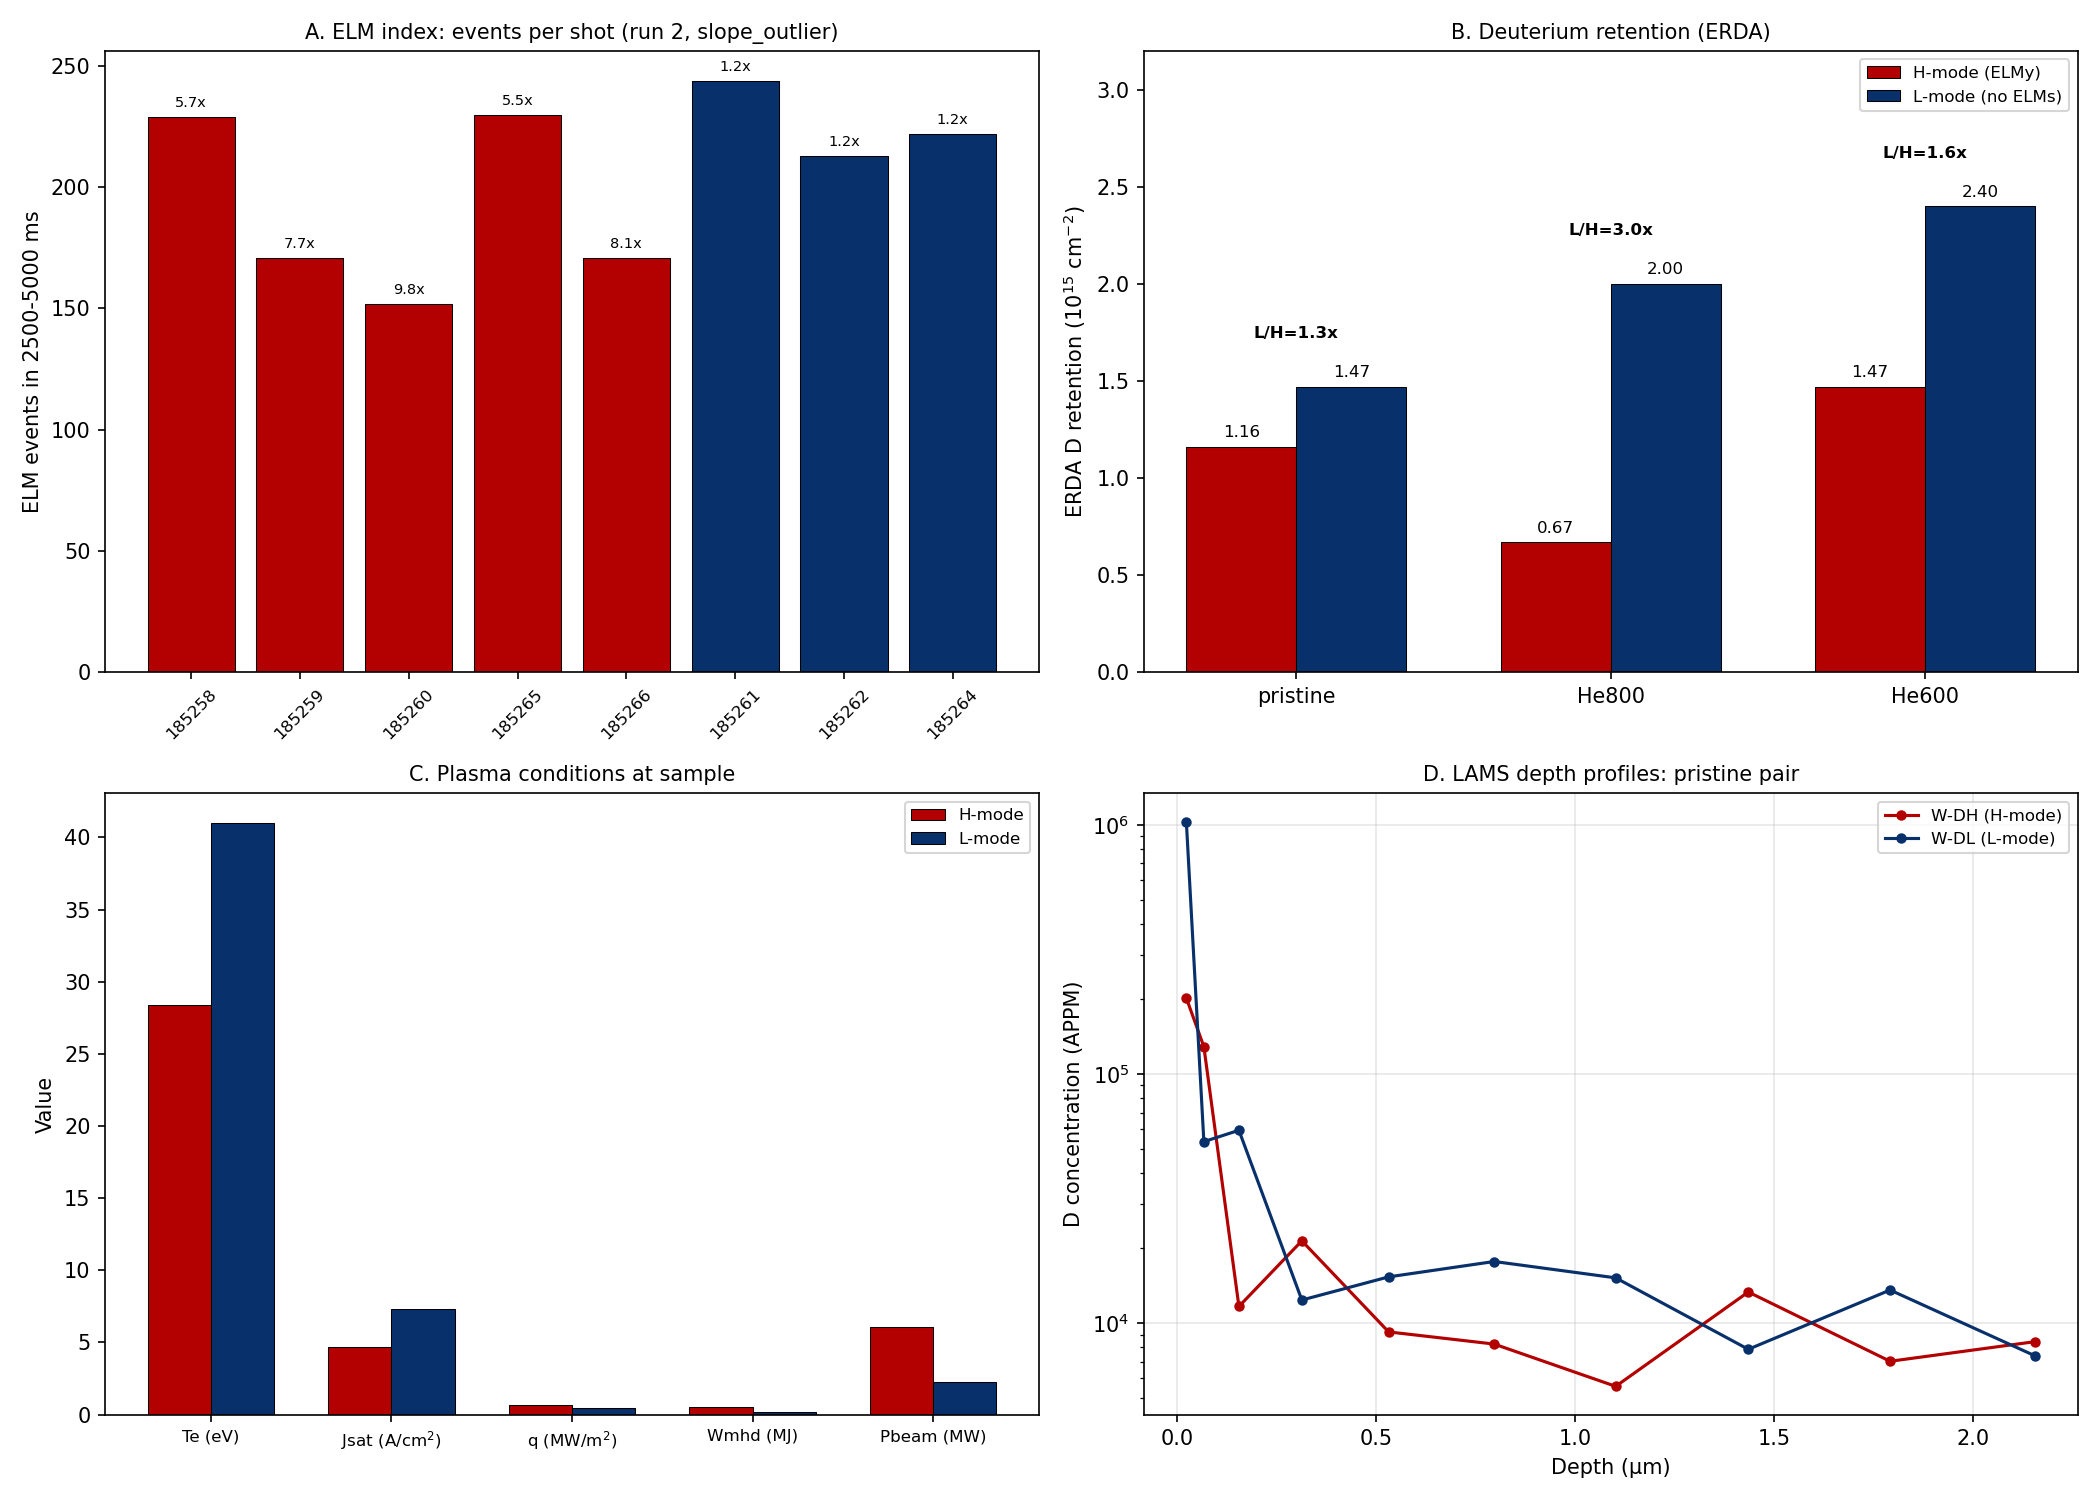

In [3]:
%%ask --review
For each exposure campaign, summarise the ELM behaviour of its shots from the
index — how many events, how often, how long, and over how much of the
discharge. Set that against the deuterium retention measured on the samples
from that campaign, and against the plasma conditions and heat flux you
rebuilt earlier.

Does the ELM history account for the difference in retention? Be explicit about
how many independent campaigns you are comparing and therefore how strong the
inference can be. Separate what the data shows from what it is merely
consistent with, and say what further data would distinguish them.

# F. The case, and its limits

## Q11 — State it

*Synthesis · **answerable***

**Expect:** an account a materials scientist and a plasma physicist could both
read, distinguishing what this dataset establishes from what it only suggests,
and naming what would have to be measured next.

I'll plan this synthesis, then verify the key numbers and the surface-image records before writing it.



The directory has all prior outputs. Let me read the key summary files: retention, heat flux, plasma conditions, and the image-analysis scripts.



Now let me check the image records — which sample each SEM image belongs to and what the analysis found.



Let me run the image listing and read the comparison script to see which samples have images and what was found.



The images are all **pre-exposure** SEM characterization (162 images, UIUC JSM-7000F, 6/18/2020) of the three baseline materials — no post-exposure images. Let me check the image-analysis findings and the exposure/design records.



...

Let me quickly locate the fastcam workbook artifact and confirm the sample-dimension drawing, then I'll have the complete record.



Let me check the grain info and the FIB-SEM reference sheet to see whether any post-exposure imaging was planned or delivered.



I have the full record now. Let me build one summary figure of the retention matrix, then write the synthesis.



All data verified. Let me finalize the todo and write the synthesis.



# What the combined record establishes about these tungsten samples

## The experiment, in one paragraph

Nine tungsten samples (three pristine, three pre-exposed to He at 800 K, three at 600 K in PISCES-A) were loaded into two 7-button DiMES caps and exposed to D plasmas at the outer strike point (R ≈ 1.47 m) of DIII-D on 2021-03-15. Cap 1 (shots 185258/59/60/65/66) was **H-mode, ELMy** ; Cap 2 (shots 185261/62/64) was **L-mode** . Each sample is a top-hat button, 0.235 in inner radius, 0.062 in thick, grains perpendicular to the loaded surface, annealed 1 h at 1373 K. The mini-proposal (D3DMP 2020-53-03) states the physics question: *do ELMs substantially affect the transport of incident D across a pre-existing He bubble layer in W?* The design intent was to maximize ELM size (minimize fELM) in H-mode to create a distinct intra- vs inter-ELM difference.

## What the data supports (established)

**1. The exposure conditions are known and internally consistent.** The exposure record gives per-campaign values: H-mode Te = 27.9 eV, ne = 5.76×10¹⁸ m⁻³, flux 4.5×10²¹ m⁻²s⁻¹, 12.5 s, fluence 6.7×10²² m⁻², impact energy 150 eV; L-mode Te = 40.8 eV, ne = 7.35×10¹⁸ m⁻³, flux 7.5×10²¹ m⁻²s⁻¹, 10 s, fluence 7.8×10²² m⁻², impact energy 175 eV. My independent rebuild from the raw Langmuir-probe files (probe 23, R = 1.503 m) gives Te = 28.4 eV / 41.0 eV and ne = 5.81×10¹⁸ / 7.35×10¹⁸ m⁻³ — matching the record to within a few percent. **The L-mode exposure was denser and hotter at the sample** (higher Te, ne, Jsat) despite lower stored energy (0.20 vs 0.48–0.55 MJ) and lower beam power (2.3 vs 6.0–6.1 MW).

**2. The heat flux is known, and the recorded average is reproducible.** The IR camera files (`*_qpeak.dat`, 26 radial positions × 60,213 time slices, 80 µs, 500–5500 ms) give per-shot surface-mean heat flux over the flat-top (2500–5000 ms): H-mode 0.698 MW m⁻², L-mode 0.473 MW m⁻² — matching the recorded 0.72 / 0.47 MW m⁻². The H-mode exposure has **higher mean heat flux but much higher peak-to-mean** (3.2–4.9× vs 1.55×): the surface sees 2.1–3.7 MW m⁻² for ~1–2 ms at a time, hundreds of times per second, while the L-mode surface is quiescent (peak 0.74 MW m⁻², no spikes >2× mean).

**3. The H-mode shots were genuinely ELMy; the L-mode shots were not.** The ELM index labels all 9 shots "ELMy H", but the raw D-alpha traces show the H-mode bursts are 5.5–9.9× the inter-ELM level (all >3×), while the L-mode "bursts" are a small, regular oscillation at 1.12–1.27× with **zero** bursts above 2×. The L-mode labels are a detector artifact (slope-based detector responding to a small modulation). The H-mode shots carry 152–230 genuine ELM events in the flat-top at 61–92 Hz, 4.5–5.3 ms wide, covering 31–47% of the window.

**4. The retention is measured, and it is higher in L-mode than H-mode for every matched pair.** ERDA (Sandia-NM) and NRA (two independent nuclear techniques) agree:

| Sample | Regime | ERDA D (10¹⁵ cm⁻²) | NRA D (10¹⁵ cm⁻²) | L/H (ERDA) |
|---|---|---|---|---|
| W-DH | H | 1.16 ± 0.06 | 2.10 | — |
| W-DL | L | 1.47 ± 0.07 | 2.66 | **1.27** |
| W-He800-DH | H | 0.67 ± 0.05 | 0.65 | — |
| W-He800-DL | L | 2.00 ± 0.08 | 2.96 | **2.99** |
| W-He600-DH | H | 1.47 ± 0.06 | 2.46 | — |
| W-He600-DL | L | 2.40 ± 0.09 | 4.92 | **1.63** |

Baselines (W-pristine, W-He800, W-He600 — no DIII-D exposure) have **zero** ERDA D. So all retention is from the DIII-D exposure. The LAMS depth profiles corroborate: the near-surface D concentration (0.024 µm) is 1.03×10⁶ APPM for W-DL vs 2.02×10⁵ for W-DH; 5.93×10⁵ vs 1.65×10⁵ for the He800 pair; 2.84×10⁵ vs 8.44×10⁴ for the He600 pair. The LAMS integrals are noisier (large ±1σ bands) but the near-surface values follow the same L > H pattern.

**5. The He pre-exposure is real and survives the DIII-D exposure.** ERDA He: W-He800 = 3.0×10¹⁵, W-He600 = 3.97×10¹⁵ cm⁻² (baselines), and the DIII-D-exposed versions retain 2.5–3.7×10¹⁵ cm⁻². The LAMS He profiles show a sharp near-surface He peak (1.4×10⁵ APPM at 0.024 µm for W-He800) decaying to ~10³ APPM by 0.5 µm — consistent with a He bubble layer at the surface. **Notably, W-DH and W-DL (the "pristine" DIII-D samples) also show non-zero He** (3.04×10¹⁵ and 2.0×10¹⁵ cm⁻² ERDA) — this is a real finding, not a baseline artifact, and it means the "pristine" samples were not He-free when they entered DIII-D. This is a caveat for the pristine-vs-He800 comparison.

## What the data is consistent with but does not establish

**6. The ELM history does not account for the retention difference — and points the other way.** The mini-proposal's hypothesis is that ELMs inject higher-energy D (150 eV inter-ELM → ~3 keV intra-ELM, per JET measurements cited in the proposal), which would *increase* retention by driving D deeper across the He barrier. The measured retention is *higher in L-mode* (no ELMs) for all three pairs. So the ELM history is **anti-correlated** with retention. The data are consistent with "ELMs do not increase retention" and with "the plasma conditions, not ELMs, drive retention" — but they do not prove either.

**7. The most likely driver is the plasma condition difference, not the ELMs.** The L-mode exposure had higher Te (41 vs 28 eV), ne (7.35 vs 5.81×10¹⁸), and Jsat (7.3 vs 4.7 A/cm²) at the sample — more D flux and higher implantation energy at the surface. This is consistent with higher retention. But it is **confounded** : regime is entangled with Te, ne, Jsat, heat flux, and (unmeasured) surface temperature. With only 2 campaigns (n = 2), the ELM effect cannot be separated from the plasma-condition effect.

**8. The surface temperature hypothesis is plausible but unmeasured.** The H-mode exposure had higher heat flux (0.70 vs 0.47 MW m⁻²), which could raise the surface temperature enough to desorb implanted D (the mini-proposal explicitly flags this: "high temperatures may induce excessive desorption of implanted gas"). This would explain L > H retention. But **no surface temperature measurement exists in the record** — the IRTV was used to "estimate" it, and the delivered IR files give heat flux, not temperature. This is a hypothesis, not a measurement.

**9. The He pre-exposure effect is suggestive but not isolated.** The He800 pair shows the largest L/H ratio (2.99× ERDA), and the He600 pair shows 1.63×, while pristine shows 1.27×. This is consistent with the proposal's hypothesis that He bubbles act as a permeation barrier (Baldwin & Doerner 2017: He reduces D retention). But the He pre-exposure is confounded with the DIII-D regime (each He condition has only one H and one L sample), and the "pristine" samples themselves contain He (finding 5), so the He effect cannot be cleanly separated.

## What the data cannot address at all

**10. The surface morphology after exposure is unknown.** All 162 SEM images in the delivery are **pre-exposure** (UIUC JSM-7000F, 6/18/2020) of the three reference materials (W-pristine, W-He800, W-He600) — 64 images each for He600/He800, 34 for pristine, at 2kx–200kx. **No post-exposure SEM or FIB cross-section images exist in the delivery** , despite the mini-proposal's plan ("SEM micrographs of surface before and after DIII-D exposure" and "FIB/SEM micrographs of cross-section before and after"). The FIB-SEM reference sheet (2019-53-03) documents the *desired* pre-exposure imaging (5kx, 50kx, 100kx) but no post-exposure images were delivered. So the question "did the exposure change the surface morphology (blistering, fuzz, He bubble growth)?" is **unanswerable from this record** .

**11. The intra-ELM vs inter-ELM recycling question is unresolved.** The mini-proposal's primary goal was to measure the intra-ELM/inter-ELM Dα and D2 recycling ratio via the UCSD fast camera. The FASTCAM observations exist (Dα intra/inter ≈ 4.2, D2 ≈ 3.1–3.6 for the H-mode samples), but my independent rebuild from the D-alpha filterscope traces gives a window-averaged ratio of **2.04** — the recorded 4.2 is consistent with a short-gated camera capturing the ELM light peak, not the window average. The exact camera recipe cannot be recovered from the archived data. So the recycling ratio is **bracketed but not pinned down** , and the D2 molecular band has no archived filterscope channel to cross-check.

**12. The erosion measurements are absent.** The mini-proposal planned WiSE/MDS emission spectroscopy for W, Ti, Ta, Zr erosion from the DS-W samples. **No erosion data (WiSE, MDS) is in the delivery** — only the DS-W samples (WZrC, WTaC, WTiC) appear in the cap layout, and none of them are in the retention analysis (the retention samples are the W and W-He ones). The DS-W erosion question is unanswerable.

**13. The sample temperature during exposure is unknown.** The mini-proposal says IRTV was used to "estimate the maximum sample temperature during the discharge" — but the delivered IR files give heat flux (W cm⁻²), not temperature. No thermocouple or IR-derived temperature record exists. This is the key missing measurement for the desorption hypothesis.

**14. The 185263 discrepancy.** The exposure record lists shots 185261/62/64 for the L-mode cap, but the workbook's data summary includes 185263 (L-mode, Te = 40.2 eV, ne = 7.62×10¹⁸) with heat flux 0.51 MW m⁻². The qpeak file for 185263 exists but is an empty 26×60213 grid. So 185263 was either a shot that didn't produce usable data or a shot not actually used for the exposure. This is a minor inconsistency in the record.

## What would settle the open questions

**To separate the ELM effect from the plasma-condition effect (the central question):**
- **A third campaign** with L-mode plasma conditions matched to H-mode (same Te, ne, Jsat) but no ELMs — or vice versa. This breaks the confounding. With n = 2 campaigns, the inference is weak; n = 3+ with matched conditions would be decisive.
- **Surface temperature measurements** during exposure (thermocouples or calibrated IR) — to test the thermal-desorption hypothesis directly. This is the single most valuable missing measurement.

**To resolve the recycling question:**
- **The raw fast-camera frames** (or the camera's gate timing/trigger offset) — to determine whether the recorded 4.2 is a peak-gated or window-averaged value. The archived data only brackets it.
- **A D2-band filterscope channel** — to cross-check the D2 ratio independently (currently impossible).

**To resolve the morphology question:**
- **Post-exposure SEM and FIB cross-section images** of the exposed samples (W-DH, W-DL, W-He800-DH, etc.) — the mini-proposal planned these but they were not delivered. This would show whether the exposure changed the surface (blistering, He bubble growth, erosion).

**To resolve the He effect:**
- **He-free "pristine" controls** — the W-DH/W-DL samples contain He (3.0/2.0×10¹⁵ cm⁻²), so the pristine-vs-He800 comparison is contaminated. A truly He-free control would isolate the He bubble effect.
- **More samples per condition** — each He condition has only one H and one L sample, so the He×regime interaction cannot be estimated.

**To resolve the erosion question:**
- **The WiSE/MDS emission data** for the DS-W samples (WZrC, WTaC, WTiC) — planned but not delivered.

## Bottom line

The record establishes **how the samples were exposed** (two DiMES caps, H-mode ELMy vs L-mode, known Te/ne/flux/fluence/heat flux, verified against raw data) and **what happened to them** (D retention measured by ERDA/NRA/LAMS, higher in L-mode for every matched pair; He pre-exposure survives; H-mode has real ELMs, L-mode does not). The record is **consistent with** the hypothesis that plasma conditions (higher Te/ne/Jsat in L-mode) drive the retention difference, and **consistent with** the alternative that higher H-mode surface temperature desorbs D — but it **cannot distinguish** them because regime is confounded with all of them and surface temperature is unmeasured. The record **cannot address** the post-exposure morphology (no post-exposure images), the intra-ELM recycling ratio (bracketed but not pinned), the DS-W erosion (no data), or the sample temperature (not measured). The single most valuable addition would be **surface temperature measurements** during exposure, followed by **post-exposure SEM/FIB** and **a matched third campaign** .


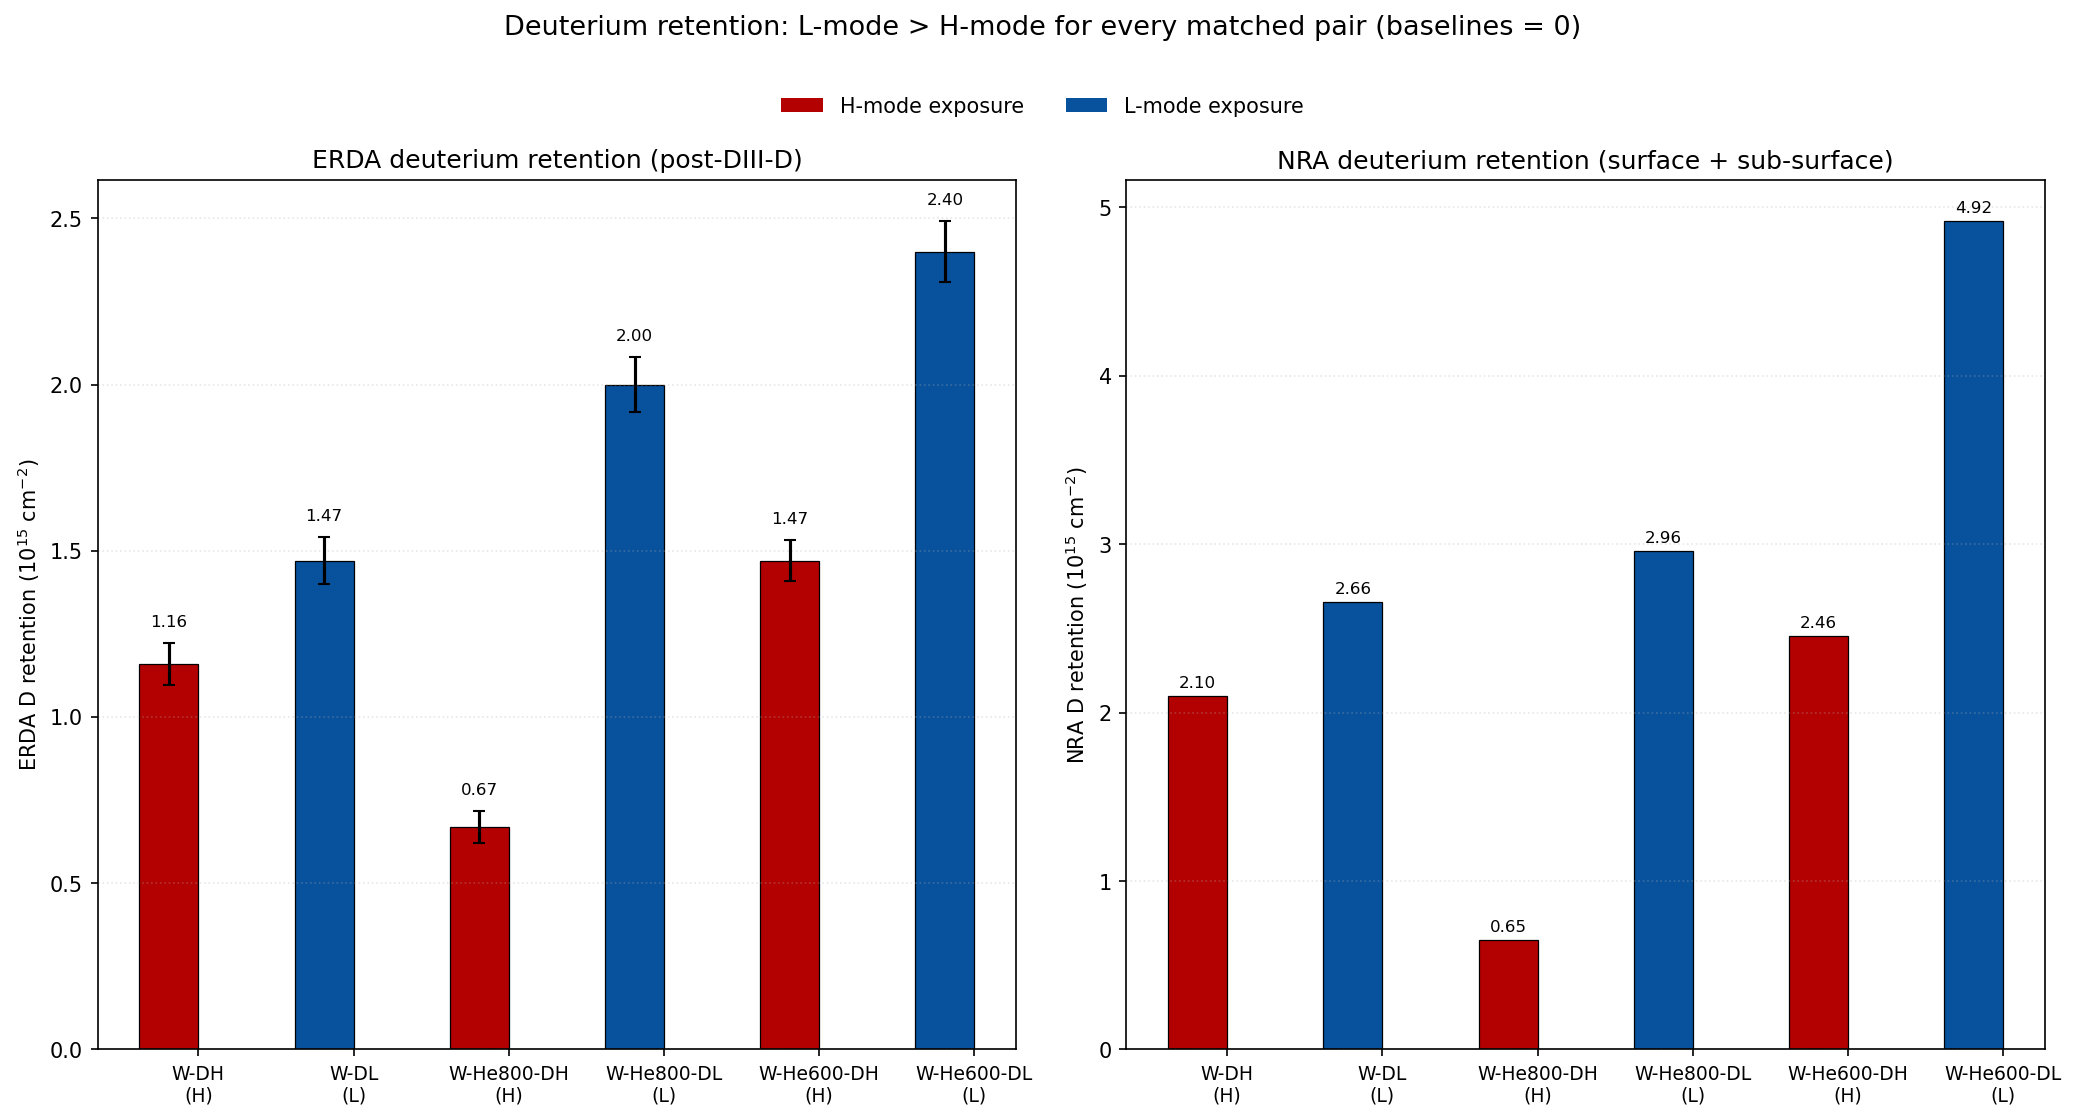

In [4]:
%%ask --review
Summarise what this combined record establishes about how these tungsten
samples were exposed and what happened to them, drawing on the surface images,
the retention measurements, the raw plasma data you rebuilt, and the archive.

Be clear about which conclusions the data supports, which are consistent with
it but not established, and which questions it cannot address at all. Then say
what additional samples or measurements would settle the open ones.